# Input Binding Data Exploration

## Purpose: 

{TODO}

## Packages and Options

In [1]:
import pandas as pd
pd.set_option('display.max_rows', 1000000)
pd.set_option('display.max_columns', 1000000)
pd.set_option('display.max_colwidth', 10000000)

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

import seaborn as sns 
import matplotlib.pyplot as plt
import itertools, glob, scipy.stats, numpy

## Literals

In [22]:
# dictionary to rename the splice junction positions to numbers
splice_junction_position_renaming = {
    "5_left": 1, 
    "5_right": 2, 
    "center_left": 3, 
    "center_right": 4, 
    "3_left": 5, 
    "3_right": 6
}

# path and regular expression to get the necessary data 
binding_data_path_regex = "../output/control_only_cleaned_input_binding_data/*-100-*csv.gz"

# different types of hierarchical clustering linkage methods 
linkage_methods = ["single", "complete", "average"]

# maximum value to show on heatmap (due to heavy skewedness of data) 
max_heatmap_value = 25000

## Load Data and Subset to Binding Information Only

In [3]:
# store all input binding data per cell line
all_binding_data = {
    "HepG2": dict(),
    "K562": dict()
}

# for each file in the data path and regex pattern 
for file in sorted(glob.glob(binding_data_path_regex)): 
    
    file = file.replace("\\", "/")
    file
    
    # parse out cell line and binding window size used 
    cell_line = file.split("/")[-1].split("-")[0]
    window_size = file.split("/")[-1].split("-")[1]
    
    # read in pandas 
    binding_data = pd.read_csv(
        file, 
        sep=",", 
        compression="gzip", 
    )
    
    # make sure no NaN values in the DataFrame
    assert binding_data.isna().values.any() == False
    
    # subset only to columns that are related to eCLIP binding
    binding_data = binding_data.loc[
         :, binding_data.columns.str.endswith(
                 ("_right", "_left")
             )
     ]
    
    # convert all 0/1 columns to int8 as they don't need 64 bits
    for column in binding_data.columns:
        if binding_data[column].dtype == 'int64':
            binding_data[column] = binding_data[column].astype("int8")

    # make sure every value in the DataFrame is either a 1 (binding) or 0 (not binding)
    assert all([binding_data[column].isin([0,1]).all() for column in binding_data.columns])
    
    # save the data 
    all_binding_data[cell_line][window_size] = binding_data


'../output/control_only_cleaned_input_binding_data/HepG2-100-50-50.csv.gz'

'../output/control_only_cleaned_input_binding_data/K562-100-50-50.csv.gz'

In [4]:
"RBP-Position Combinations that are all 0"

# for each cell line and window size 
for cell_line in all_binding_data: 
    for window_size in all_binding_data[cell_line]:
        "{} {}".format(cell_line, window_size)
        
        tmp_df = all_binding_data[cell_line][window_size]
        
        # list to indicate all those RBP-position combinations that are empty 
        empty=[]
        
        # check if there are RBP positions that only have 0's
        for column in tmp_df.columns:
            if (tmp_df[column]==0).all(): 
                empty.append(column)
                
        print(empty)

'RBP-Position Combinations that are all 0'

'HepG2 100'

['DHX30_5_left', 'HNRNPA1_5_left', 'SAFB_5_left', 'TBRG4_5_left', 'DHX30_5_right', 'HNRNPU_5_right', 'POLR2G_5_right', 'TBRG4_5_right', 'DHX30_center_left', 'POLR2G_center_left', 'TBRG4_center_left', 'DHX30_center_right', 'POLR2G_center_right', 'TBRG4_center_right', 'POLR2G_3_left', 'TBRG4_3_left', 'HNRNPA1_3_right', 'POLR2G_3_right', 'TBRG4_3_right', 'XRCC6_3_right']


'K562 100'

['AARS_5_left', 'GNL3_5_left', 'PUS1_5_left', 'SBDS_5_left', 'SUPV3L1_5_left', 'AARS_5_right', 'ABCF1_5_right', 'HNRNPU_5_right', 'PUS1_5_right', 'RPS11_5_right', 'RYBP_5_right', 'SBDS_5_right', 'SF3B1_5_right', 'UTP3_5_right', 'WDR3_5_right', 'GNL3_center_left', 'PUS1_center_left', 'SBDS_center_left', 'AARS_center_right', 'GNL3_center_right', 'PUS1_center_right', 'RPS11_center_right', 'SBDS_center_right', 'SLBP_center_right', 'WDR3_center_right', 'AARS_3_left', 'PUS1_3_left', 'SBDS_3_left', 'UTP3_3_left', 'AARS_3_right', 'GNL3_3_right', 'HNRNPU_3_right', 'PUS1_3_right', 'SBDS_3_right', 'SUPV3L1_3_right', 'UTP3_3_right', 'WDR3_3_right']


## Which RBPs Bind the Most When Considering All 6 Positions?

<Figure size 2000x600 with 0 Axes>

Text(0.5, 1.0, 'HepG2: 100 Window')

<Axes: title={'center': 'HepG2: 100 Window'}>

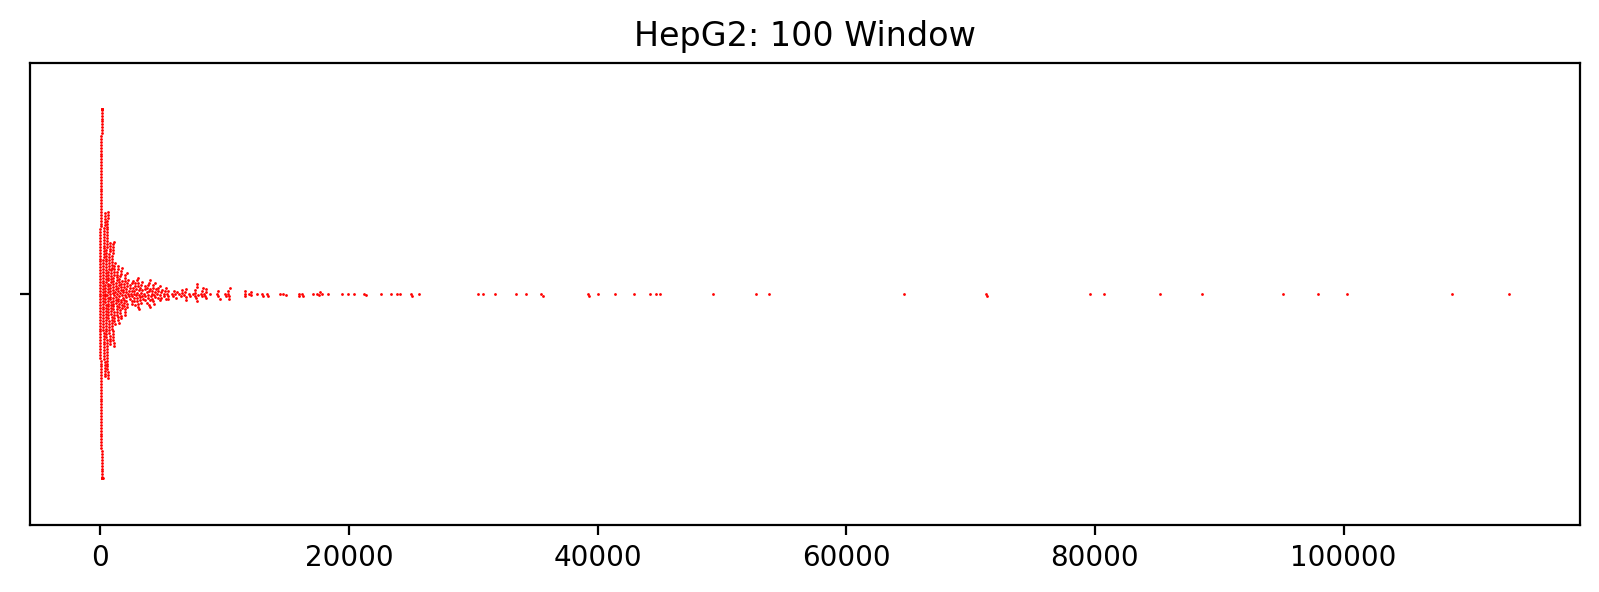

<Figure size 8000x400 with 0 Axes>

Text(0.5, 1.0, 'HepG2: 100 Window')

<Axes: title={'center': 'HepG2: 100 Window'}>

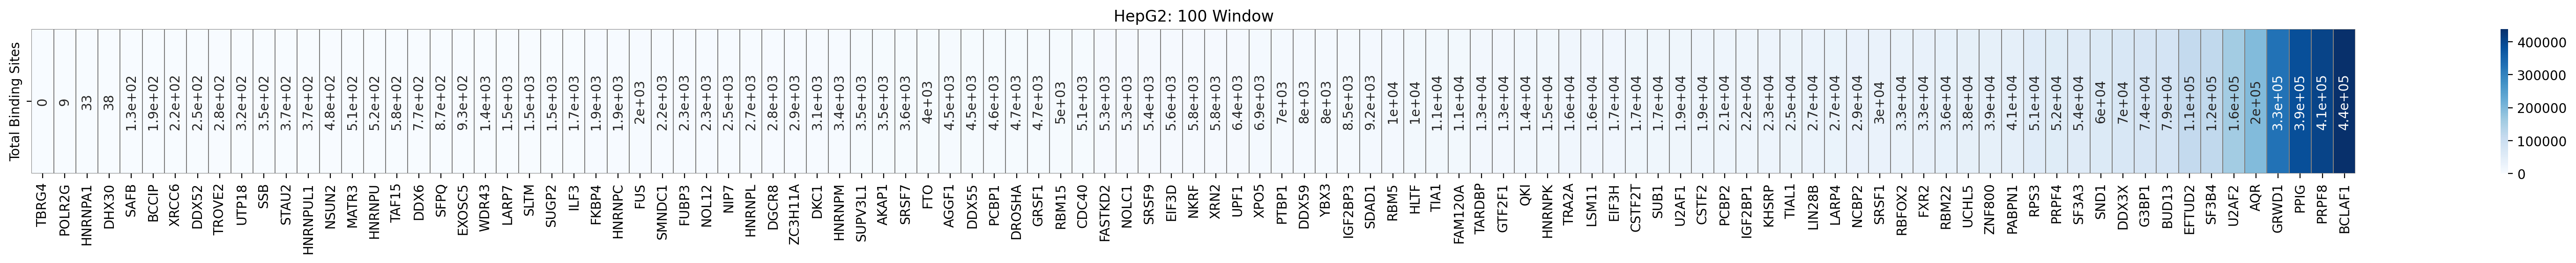

<Figure size 2000x600 with 0 Axes>

Text(0.5, 1.0, 'K562: 100 Window')

<Axes: title={'center': 'K562: 100 Window'}>

C:\Users\yragh\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 13.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


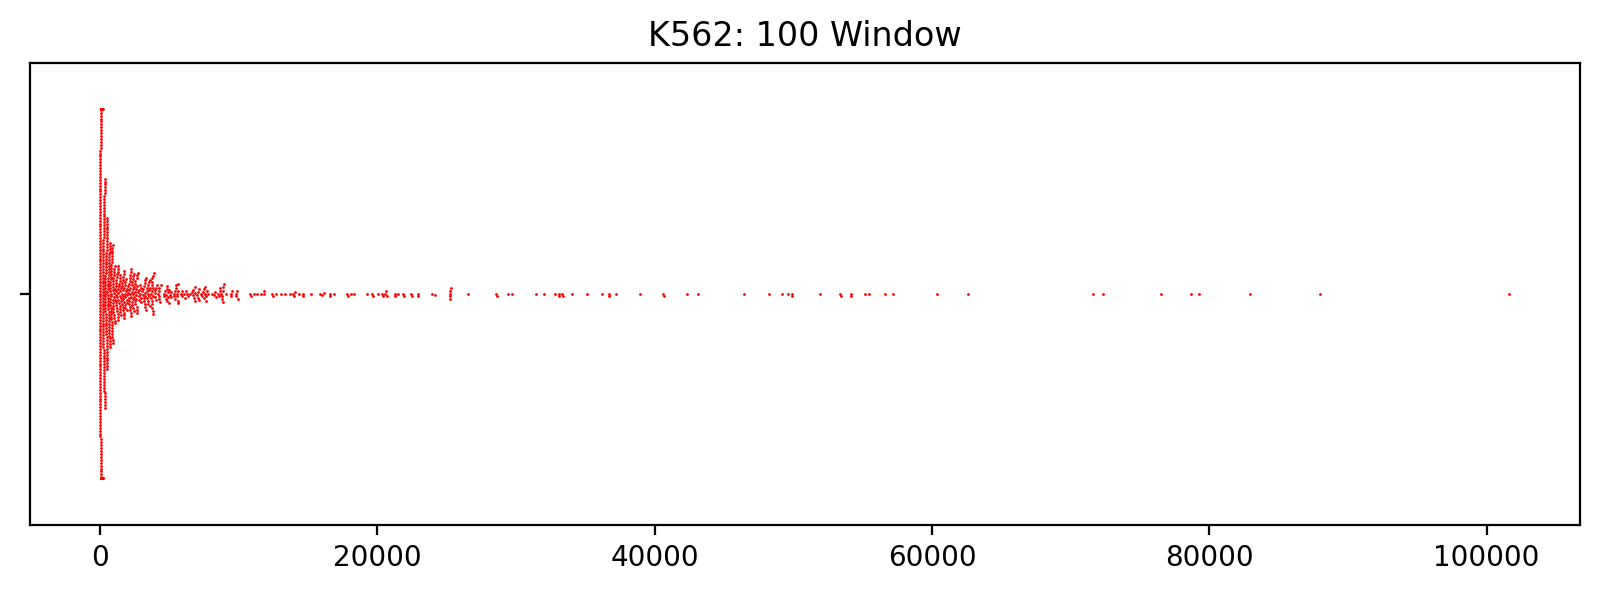

<Figure size 8000x400 with 0 Axes>

Text(0.5, 1.0, 'K562: 100 Window')

<Axes: title={'center': 'K562: 100 Window'}>

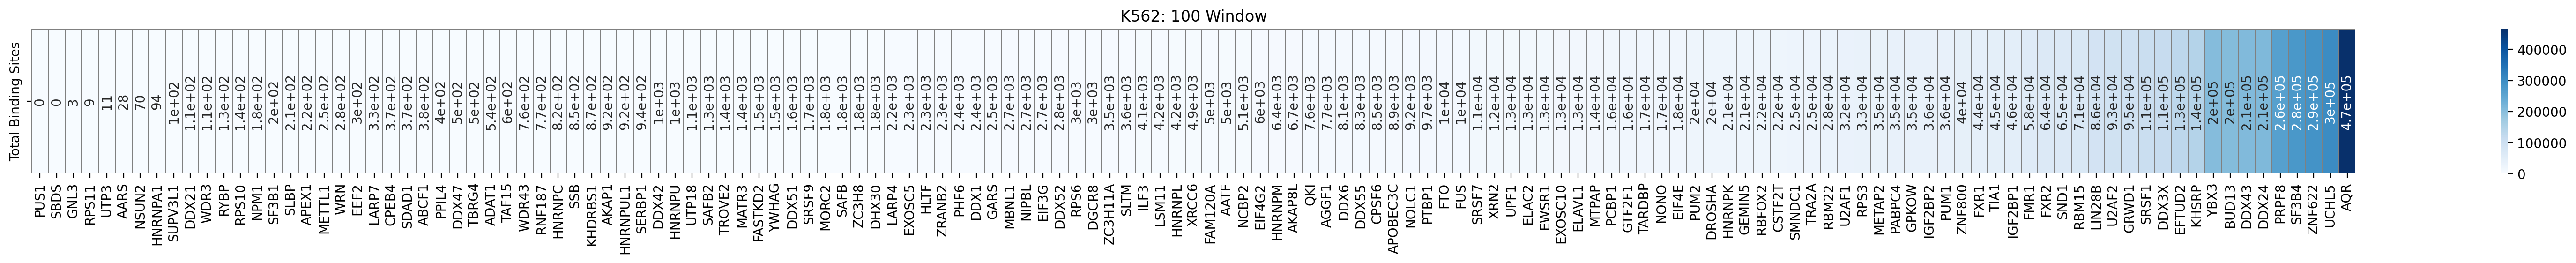

In [5]:
# for each cell line and window size 
for cell_line in all_binding_data:     
    for window_size in all_binding_data[cell_line]: 
        
        # get number of binding sites per each RBP-position combination 
        tmp_num_binding_sites = all_binding_data[cell_line][window_size].sum(axis=0)        
        
        # parse out each unique RBP in the dataset 
        all_rbps = list(set([rbp_position.split("_")[0] for rbp_position in tmp_num_binding_sites.index]))
        
        # create lists to be index and values for new DataFrame 
        # index = "RBP" and value = "number of times RBP bound to any position"
        df_index = []
        total_binding = []
        
        # for each unique rbp 
        for rbp in all_rbps: 
            
            # sum up number of binding sites across all positions for each rbp and save
            total_binding.append(
                tmp_num_binding_sites[tmp_num_binding_sites.index.str.contains(rbp)].sum()
            )
            # add RBP to index 
            df_index.append(rbp)
        
        # create dataframe with one column and sort RBPs by total number of binding sites 
        tmp_df = pd.DataFrame(total_binding, index=df_index, columns=["Total Binding Sites"]).sort_values("Total Binding Sites").T
        
        # create horizontal swarmplot
        plt.figure(figsize=(10,3), dpi=200)
        plt.title("{}: {} Window".format(cell_line, window_size), fontsize=12)
        sns.swarmplot(tmp_num_binding_sites, orient="h", size=1, color="red")
        plt.show()
        
        # create horizontal heatmap and include rotated annotations for number of total binding sites 
        plt.figure(figsize=(40,2), dpi=200)
        plt.title("{}: {} Window".format(cell_line, window_size), fontsize=12)
        sns.heatmap(tmp_df, linewidth=0.1, linecolor="grey", annot=True, annot_kws={'rotation':90}, cmap="Blues")
        plt.show()

## What is the Distribution of Number of Bindings per Each RBP-Position Combination?

In [6]:
# dict to store number of binding sites for each RBP position combination 
# {cell line: {window size: value}}
num_binding_sites = {}

# for each cell line and window size
for cell_line in all_binding_data: 
    num_binding_sites[cell_line] = {}
    
    for window_size in all_binding_data[cell_line]: 
        
        # sum up the number of binding sites per RBP-Position combination and save to dict 
        tmp_num_binding_sites = all_binding_data[cell_line][window_size].sum(axis=0)        
        num_binding_sites[cell_line][window_size] = tmp_num_binding_sites


#### Histogram of all RBP-Position combinations

<Axes: ylabel='Count'>

<Axes: ylabel='Count'>

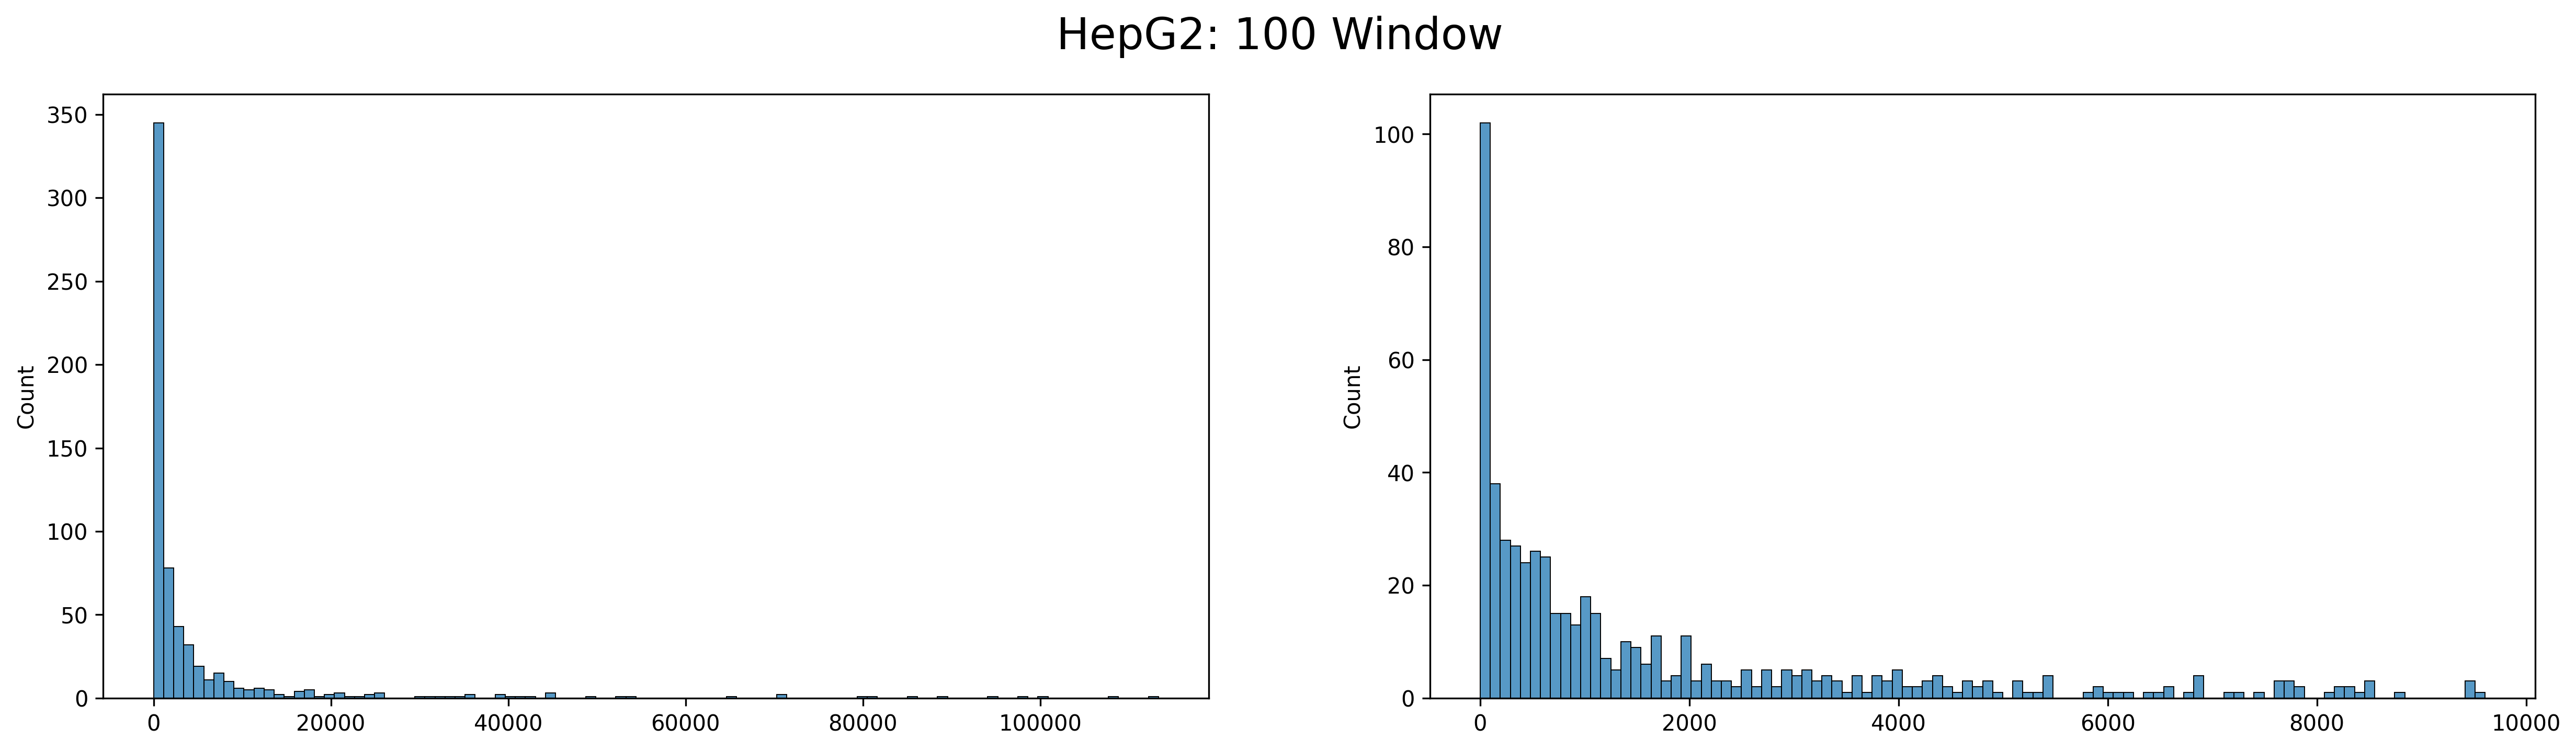

<Axes: ylabel='Count'>

<Axes: ylabel='Count'>

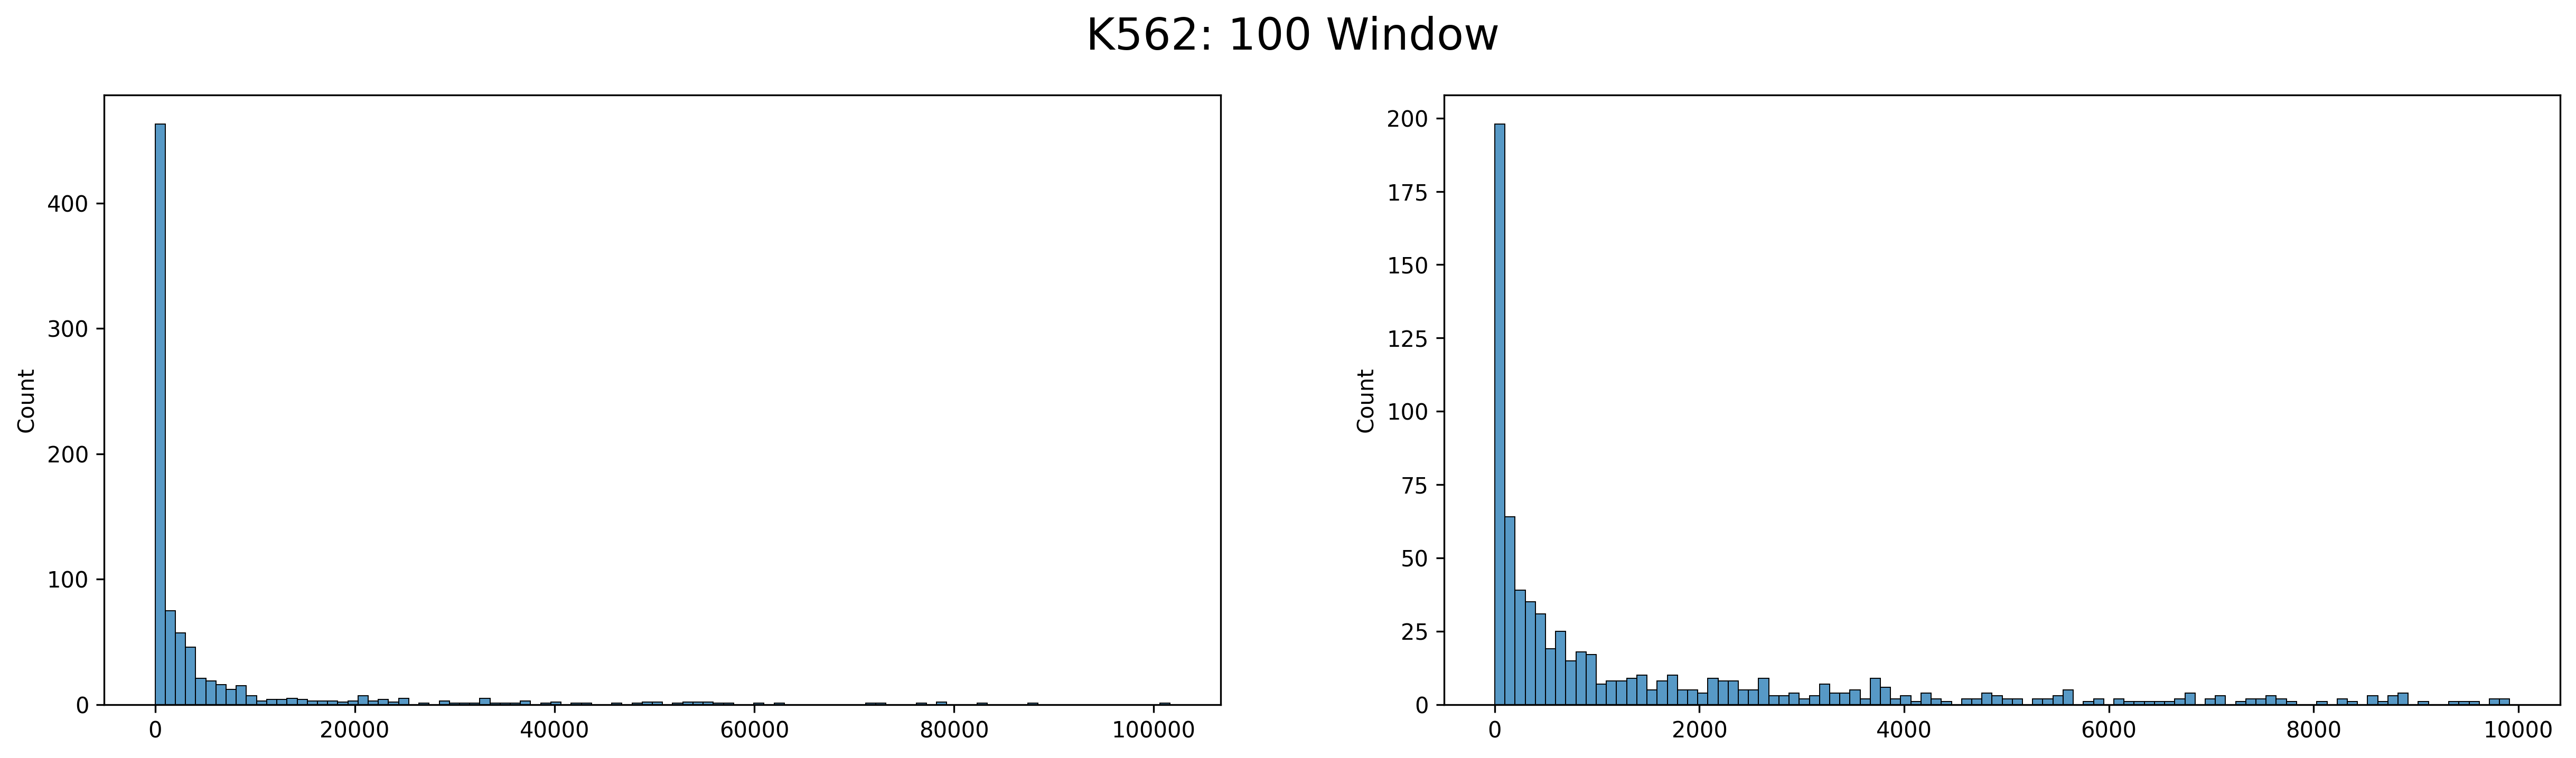

In [7]:
# for each cell line and window size 
for cell_line in num_binding_sites: 
    for window_size in num_binding_sites[cell_line]: 
        
        tmp_num_binding_sites = num_binding_sites[cell_line][window_size]
        
        # create 2 subplots 
        fig, ax = plt.subplots(1, 2, figsize=(20,5), dpi=300)
        
        # first histogram plot uses the entirety of the data 
        # due to severe skewdness, the 2nd plot subsets the x axis by a lot 
        sns.histplot(tmp_num_binding_sites, bins=100, ax=ax[0])
        sns.histplot(tmp_num_binding_sites[tmp_num_binding_sites.between(0,10000)], bins=100, ax=ax[1])
        
        _=plt.suptitle("{}: {} Window".format(cell_line, window_size), fontsize=20)
        plt.show()

#### Swarmplot of all RBP-Position Combinations

<Figure size 1600x600 with 0 Axes>

<Axes: >

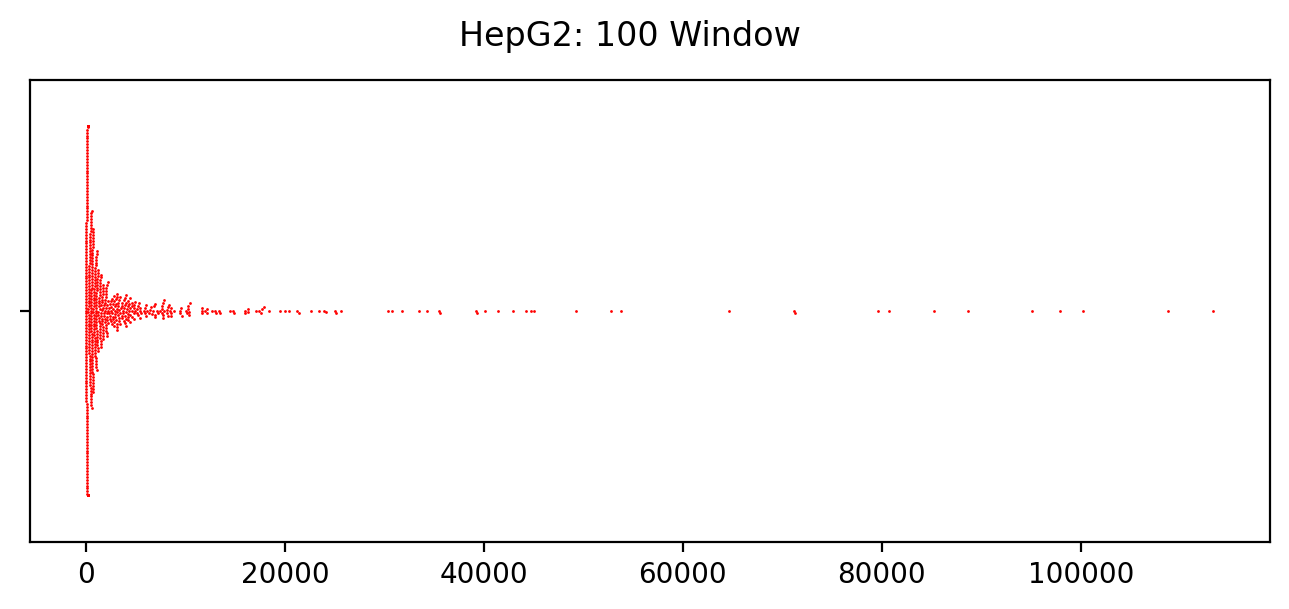

<Figure size 1600x600 with 0 Axes>

<Axes: >

C:\Users\yragh\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 17.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


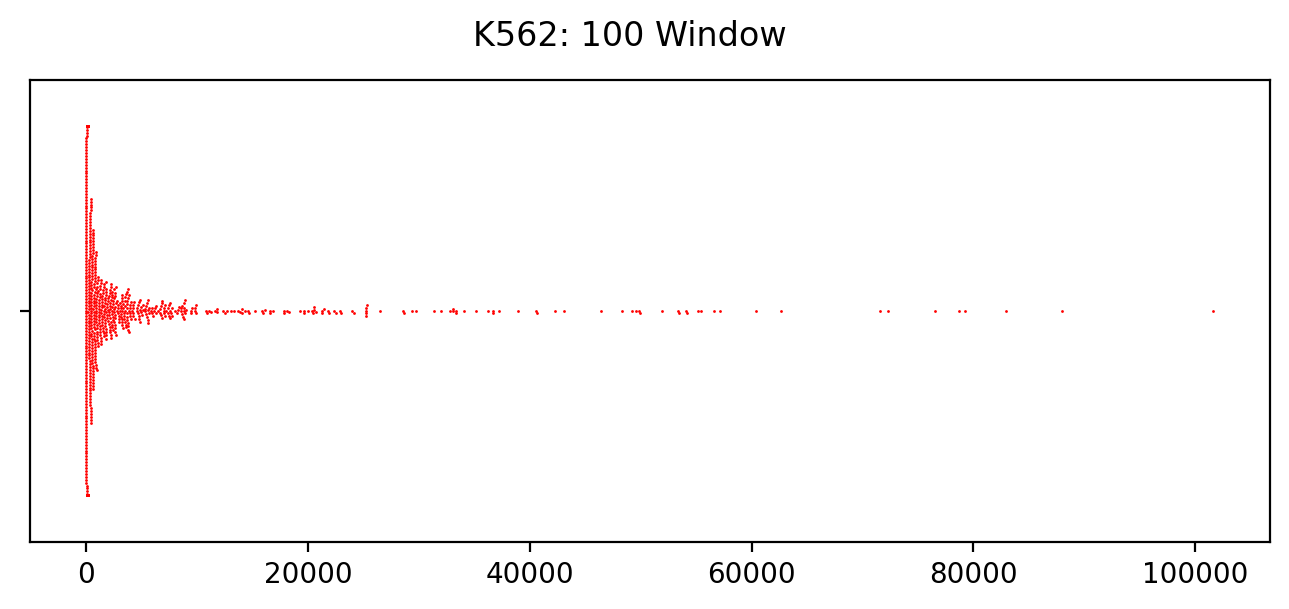

In [8]:
# for each cell line and window size 
for cell_line in num_binding_sites: 
    for window_size in num_binding_sites[cell_line]: 
        
        tmp_num_binding_sites = num_binding_sites[cell_line][window_size]
        
        # create a swarmplot that is horizontal and small point size because there are a lot of points near 0 
        plt.figure(figsize=(8,3), dpi=200)
        
        sns.swarmplot(tmp_num_binding_sites, orient="h", size=1, color="red")
        
        _=plt.suptitle("{}: {} Window".format(cell_line, window_size), fontsize=12)
        plt.show()

#### Heatmap + ClusterMap w/ matrix of dimension (# RBPs, 6)

In [92]:
rbp_by_position_matrix = {}

# for each cell line and window size 
for cell_line in num_binding_sites: 
    rbp_by_position_matrix[cell_line] = {}
    
    for window_size in num_binding_sites[cell_line]: 
        
        tmp_num_binding_sites = num_binding_sites[cell_line][window_size]
        
        # create a dictionary for this combination of cell line and window size which will be turned into a DataFrame
        # {"rbp": {"position": "value"}}
        num_binding_sites_df = {}
        
        # for each RBP-position combination and number of total binding sites
        for index, value in tmp_num_binding_sites.items(): 
            
            # for each position in a skipped exon 
            for position_string in splice_junction_position_renaming:
                
                # if position in RBP-position combination matches the "position_string"
                if position_string in index: 
                    # get rbp and position 
                    rbp = index.split("_")[0]
                    position = splice_junction_position_renaming[position_string]
                    
                    # if rbp not already in dictionary, then add it 
                    if rbp not in num_binding_sites_df: 
                        num_binding_sites_df[rbp] = {}
                    
                    # separate out the position and RBP into 2 dimensions
                    num_binding_sites_df[rbp][position] = value
                    
                    # end the innermost loop if you've already found the correct position 
                    break
        
        # from dictionary, convert to DataFrame where the rows are a given position and each column is an RBP 
        num_binding_sites_df = pd.DataFrame.from_dict(num_binding_sites_df, orient="columns")
        num_binding_sites_df.shape

        rbp_by_position_matrix[cell_line][window_size] = num_binding_sites_df

(6, 105)

(6, 139)

<Axes: >

<Axes: >

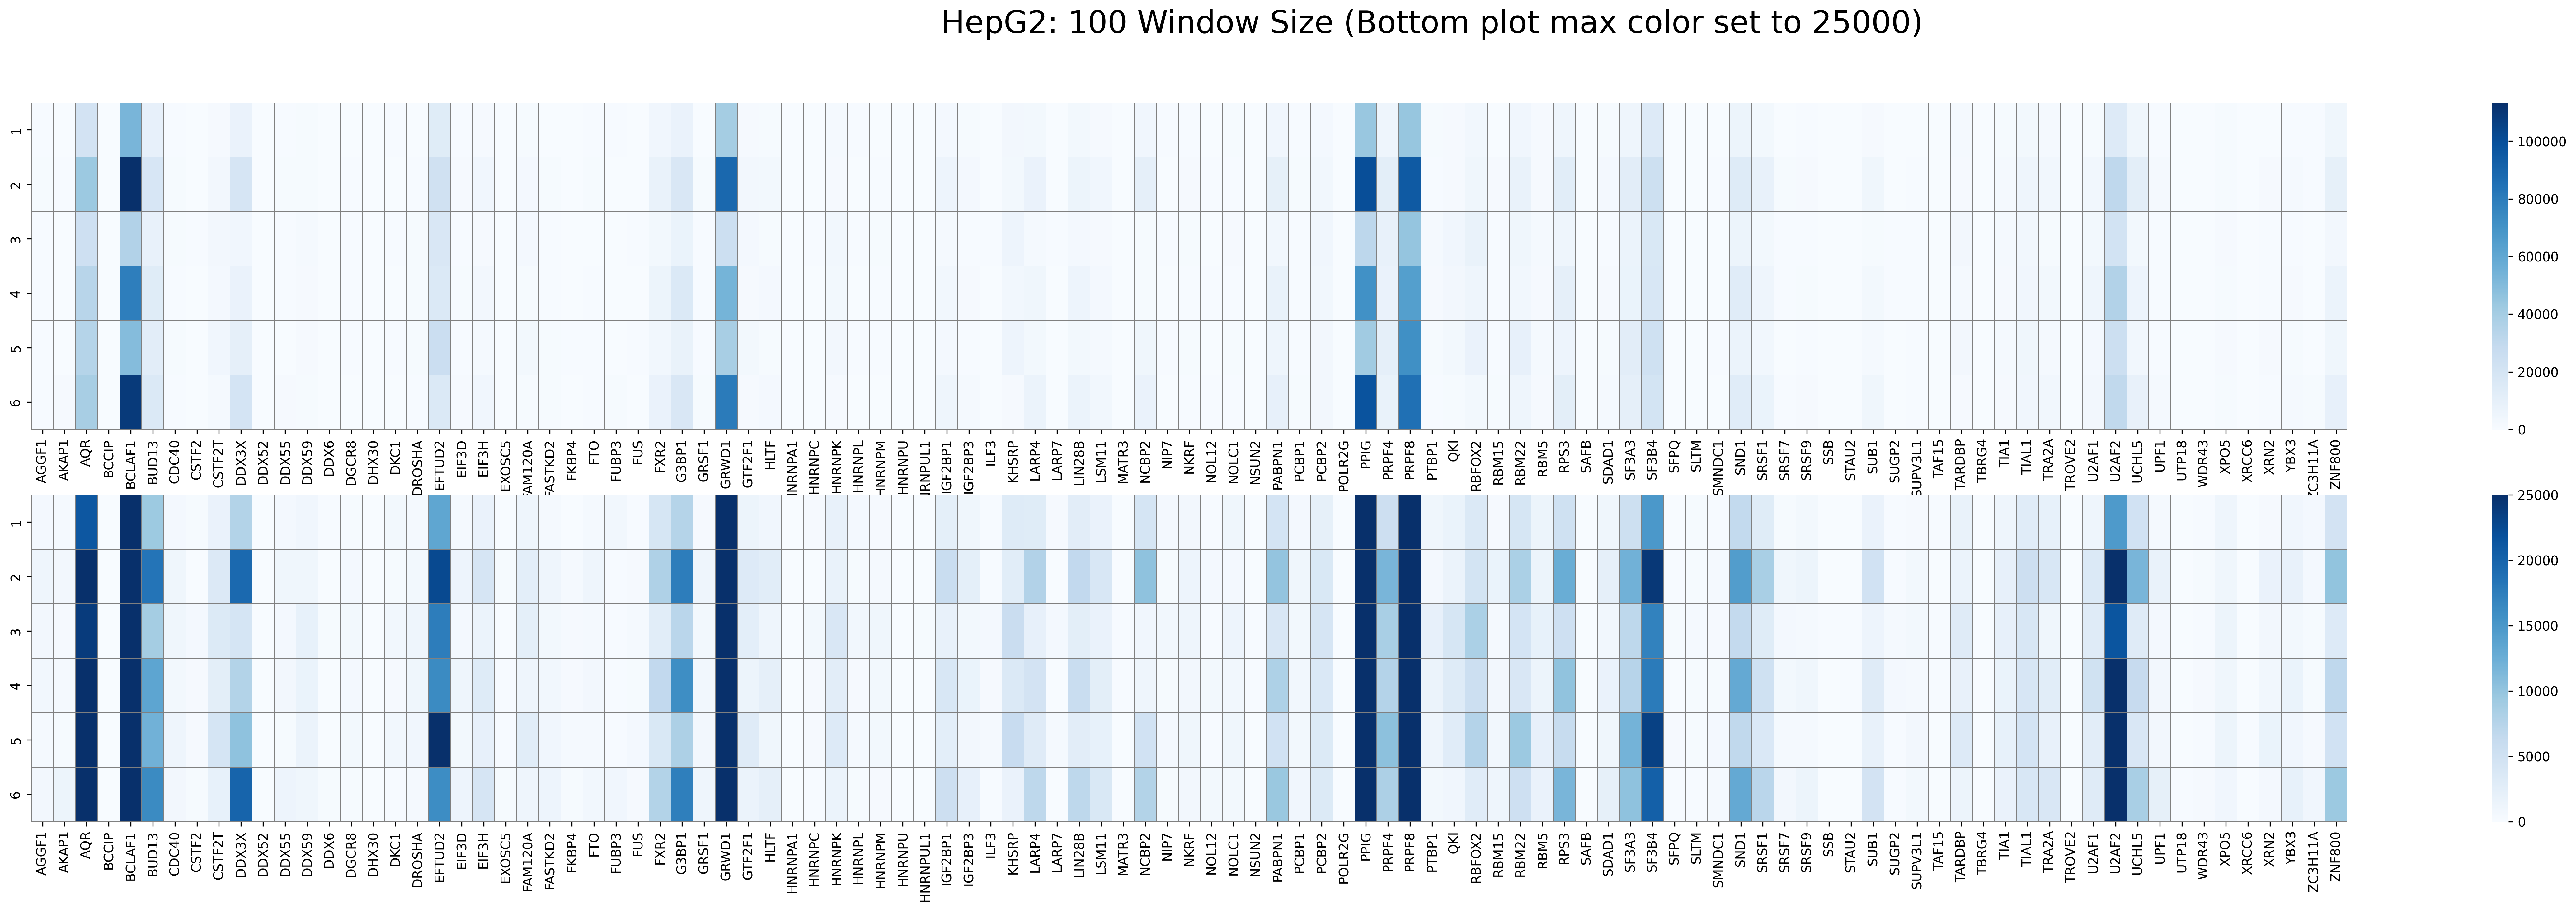

Text(0.5, 0.98, 'HepG2: 100 Window Size')

Text(0.5, 0.98, 'HepG2: 100 Window Size (Max color set to 25000)')

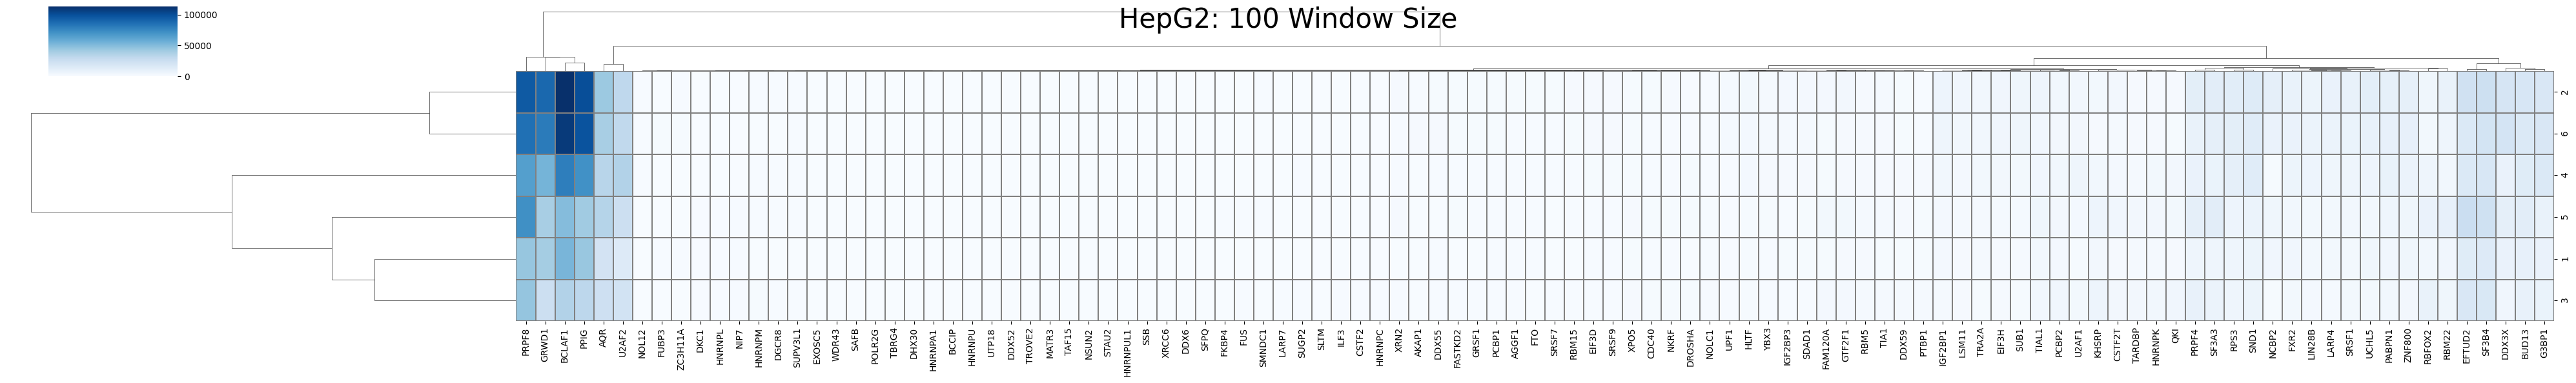

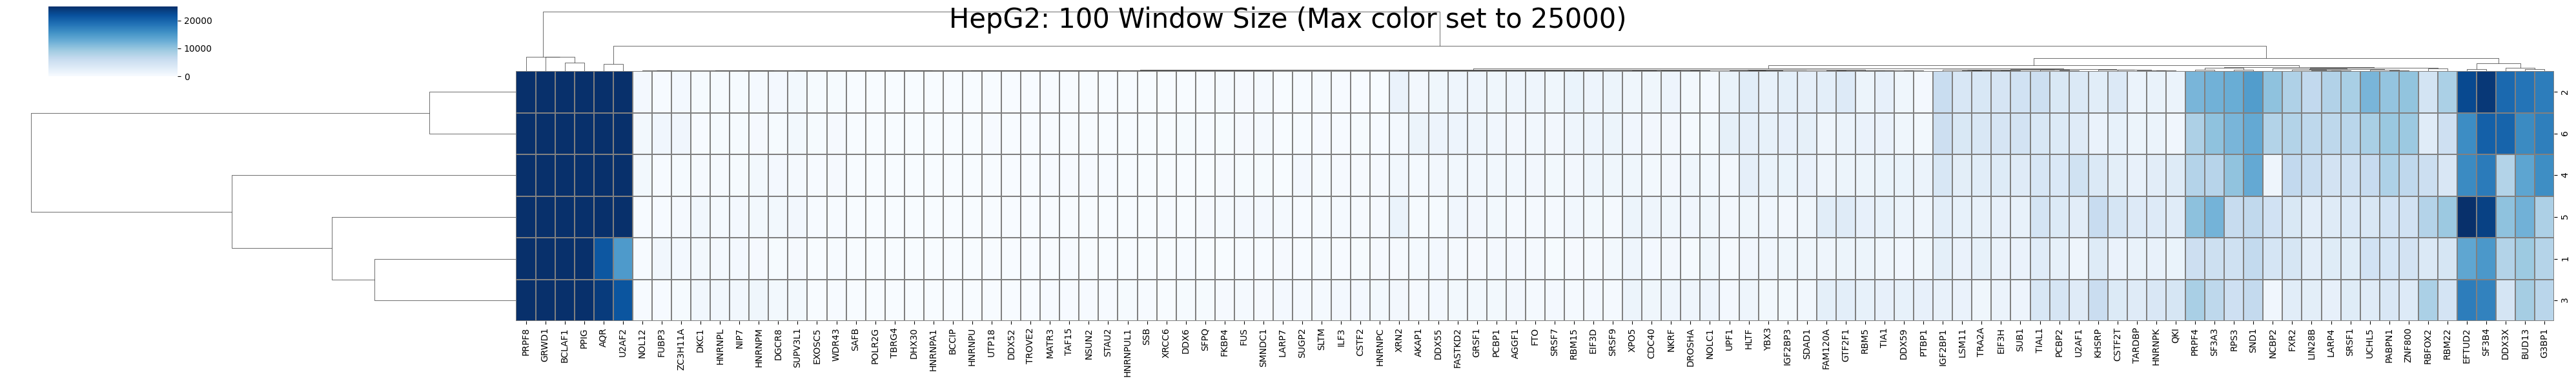

<Axes: >

<Axes: >

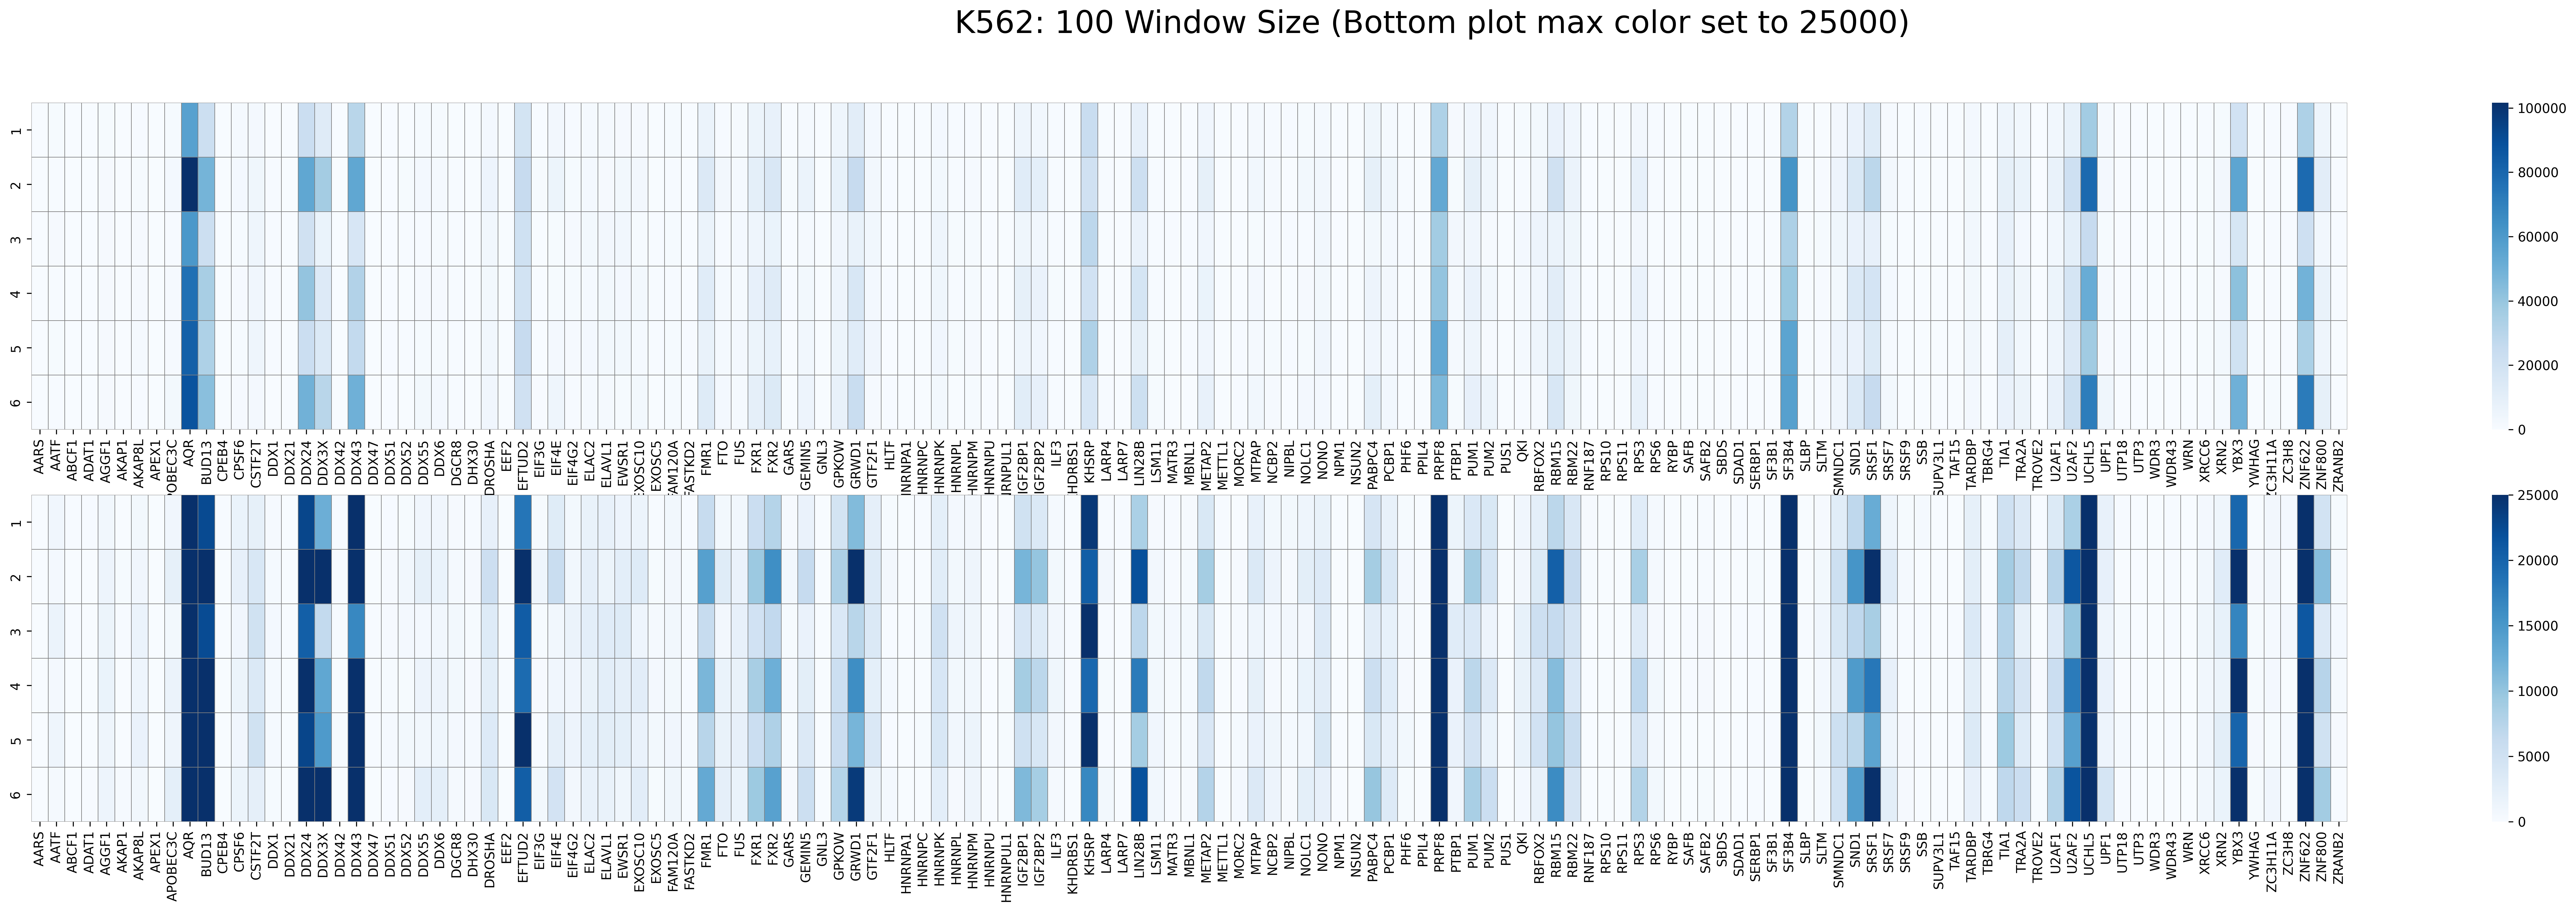

Text(0.5, 0.98, 'K562: 100 Window Size')

Text(0.5, 0.98, 'K562: 100 Window Size (Max color set to 25000)')

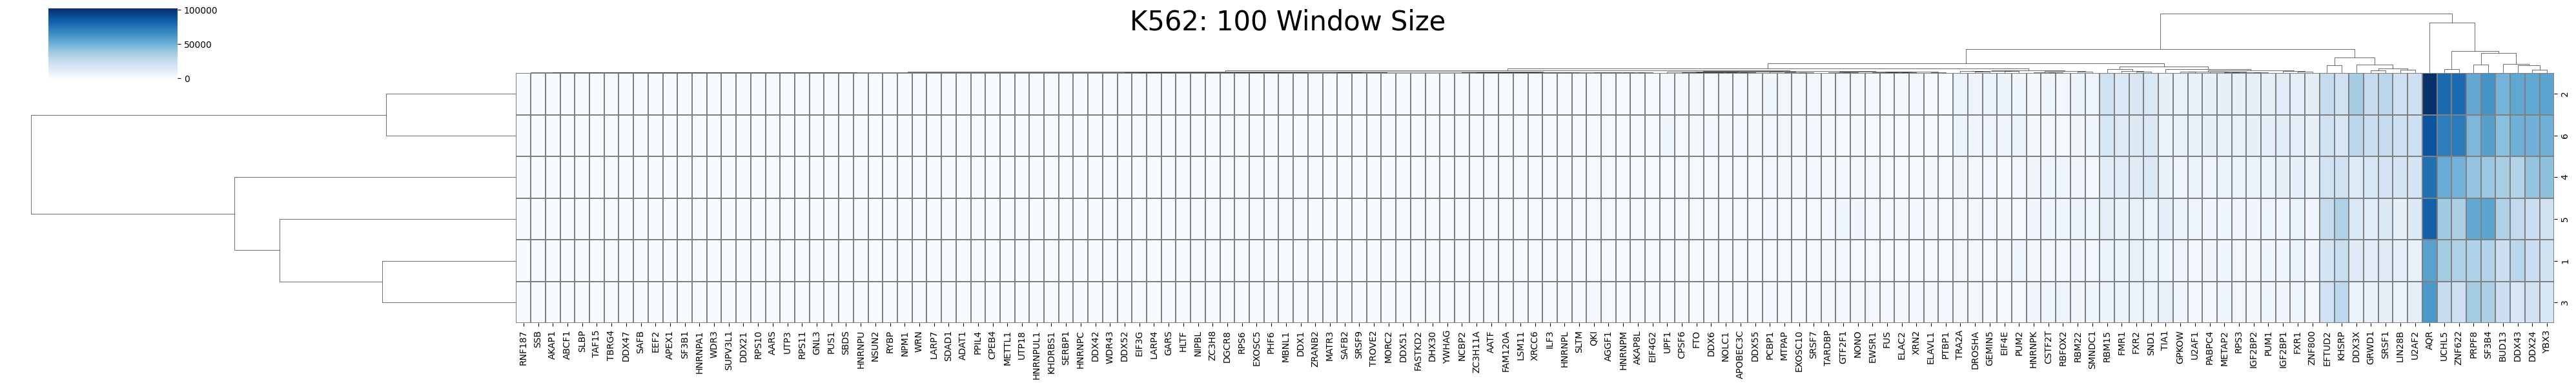

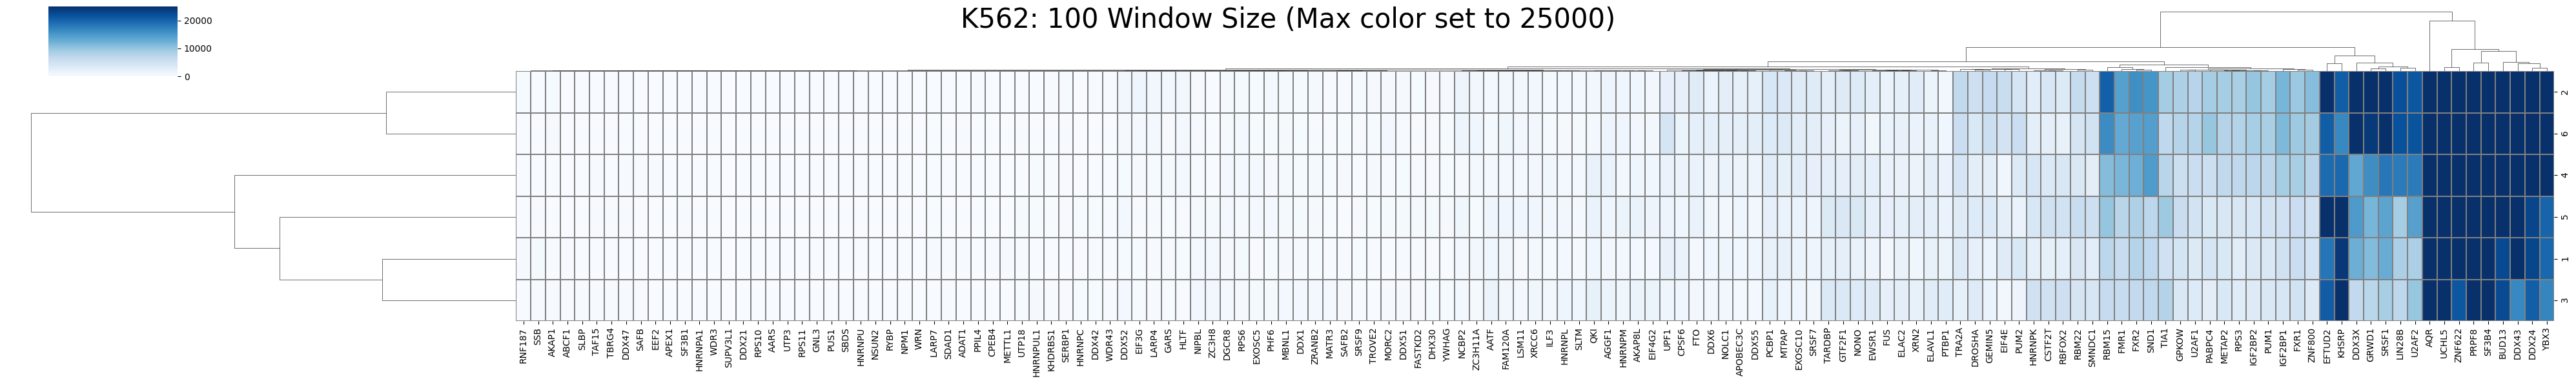

In [93]:
# for each cell line and window size 
for cell_line in num_binding_sites: 
    for window_size in num_binding_sites[cell_line]: 
        
        num_binding_sites_df = rbp_by_position_matrix[cell_line][window_size]
        
        # create two subplots vertically 
        fig, ax =plt.subplots(2, 1, dpi=300, figsize=(40, 10))
        _=plt.suptitle("{}: {} Window Size (Bottom plot max color set to {})".format(cell_line, window_size, max_heatmap_value), fontsize=24)
        
        # first subplot is with all the values 
        # second subplot caps the maximum value color due to the outliers dominating the max color 
        sns.heatmap(num_binding_sites_df, linewidths=0.1, linecolor="gray", ax=ax[0], cmap="Blues")
        sns.heatmap(num_binding_sites_df, linewidths=0.1, linecolor="gray", vmin=0, vmax=25000, ax=ax[1], cmap="Blues")
    
        plt.show()
        
        # now create two clustermaps where the only difference between both of them 
        # is that the first clustermap doesn't have a limit to the max color and the second one does 
        plot=sns.clustermap(num_binding_sites_df, figsize=(40, 6), linewidths=0.1, linecolor="gray", cmap="Blues")
        plot.fig.suptitle("{}: {} Window Size".format(cell_line, window_size), fontsize=30,)
        
        plot=sns.clustermap(num_binding_sites_df, figsize=(40, 6), linewidths=0.1, linecolor="gray", vmin=0, vmax=25000, cmap="Blues")
        plot.fig.suptitle("{}: {} Window Size (Max color set to {})".format(cell_line, window_size, max_heatmap_value), fontsize=30,)
        
        plt.show()
        

## What is the Distribution of the % of RBP-Position Combinations Bound per `SE` Event?

<Axes: ylabel='Percent'>

<Axes: ylabel='Percent'>

Text(0.5, 0.98, 'HepG2: 100 Window Size')

[Text(0.5, 0, 'Number of RBP-Position Combinations Bound')]

[Text(0.5, 0, 'Percent of RBP-Position Combinations Bound')]

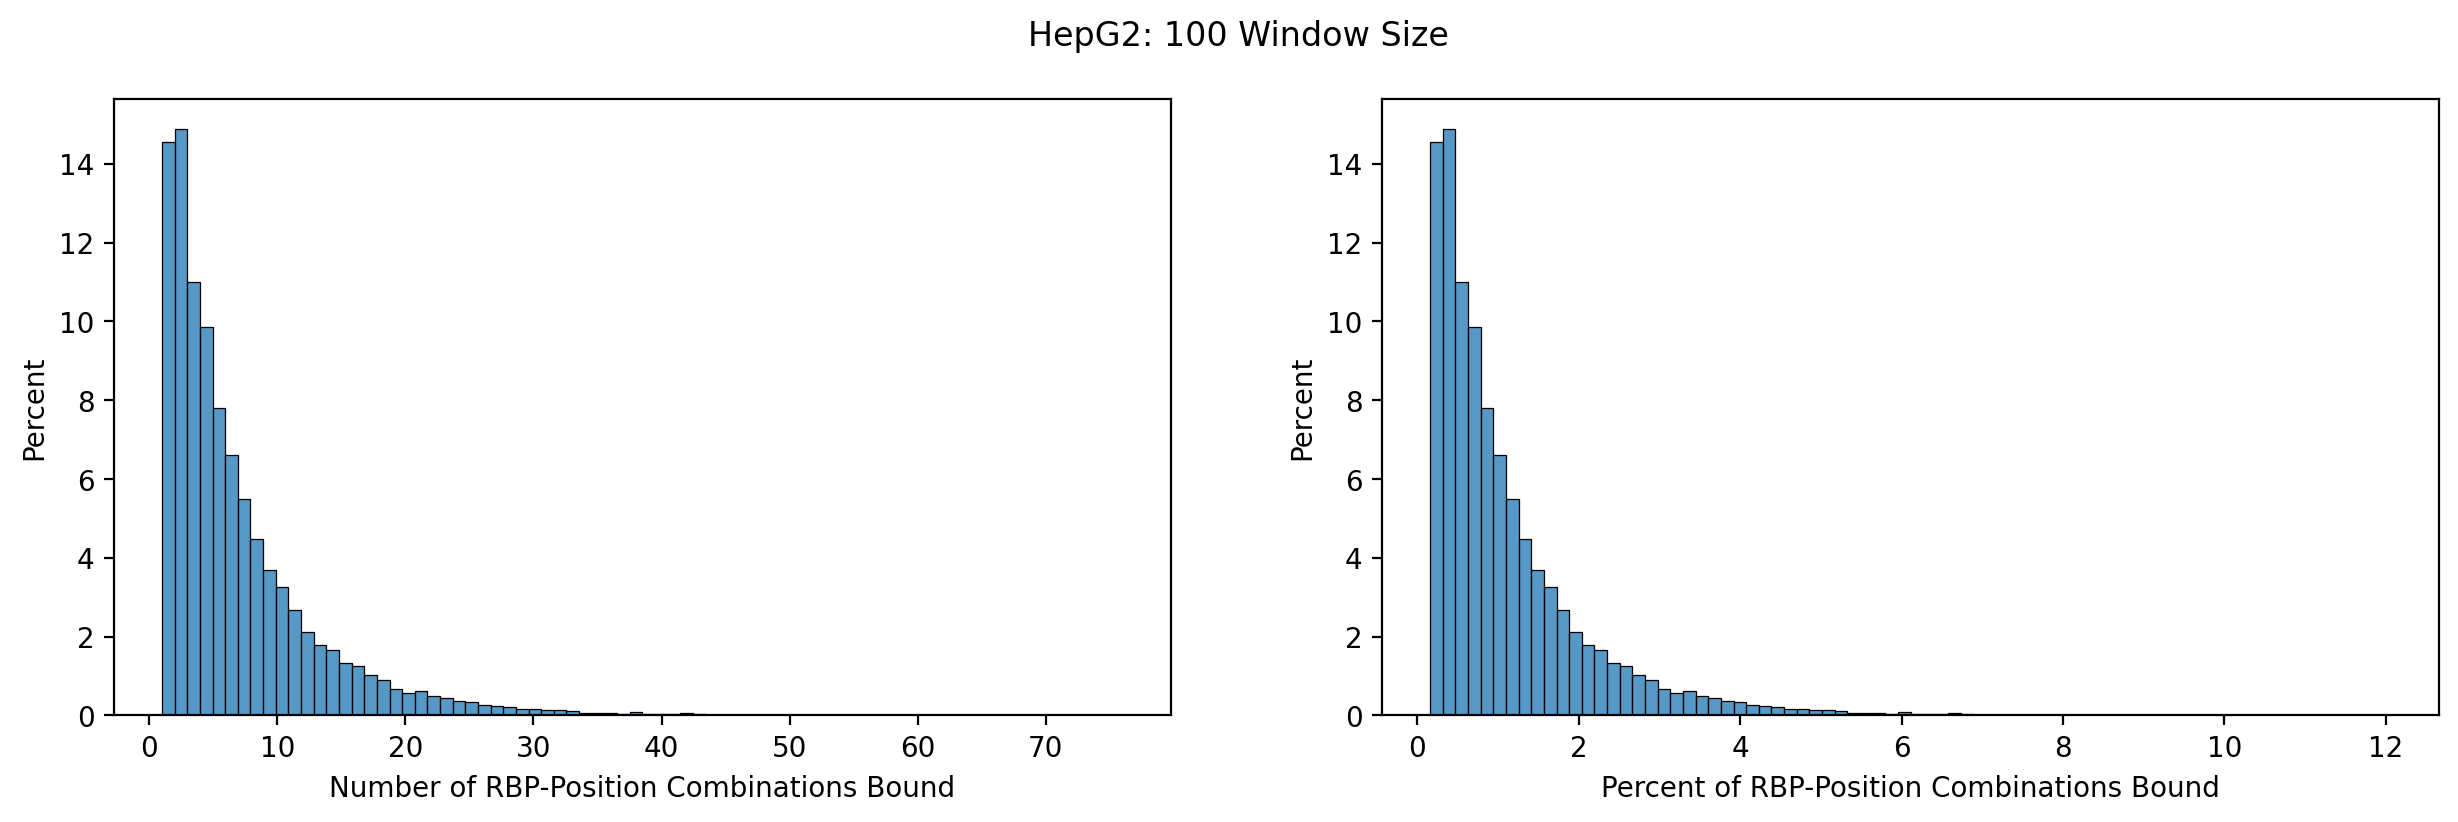

<Axes: ylabel='Percent'>

<Axes: ylabel='Percent'>

Text(0.5, 0.98, 'K562: 100 Window Size')

[Text(0.5, 0, 'Number of RBP-Position Combinations Bound')]

[Text(0.5, 0, 'Percent of RBP-Position Combinations Bound')]

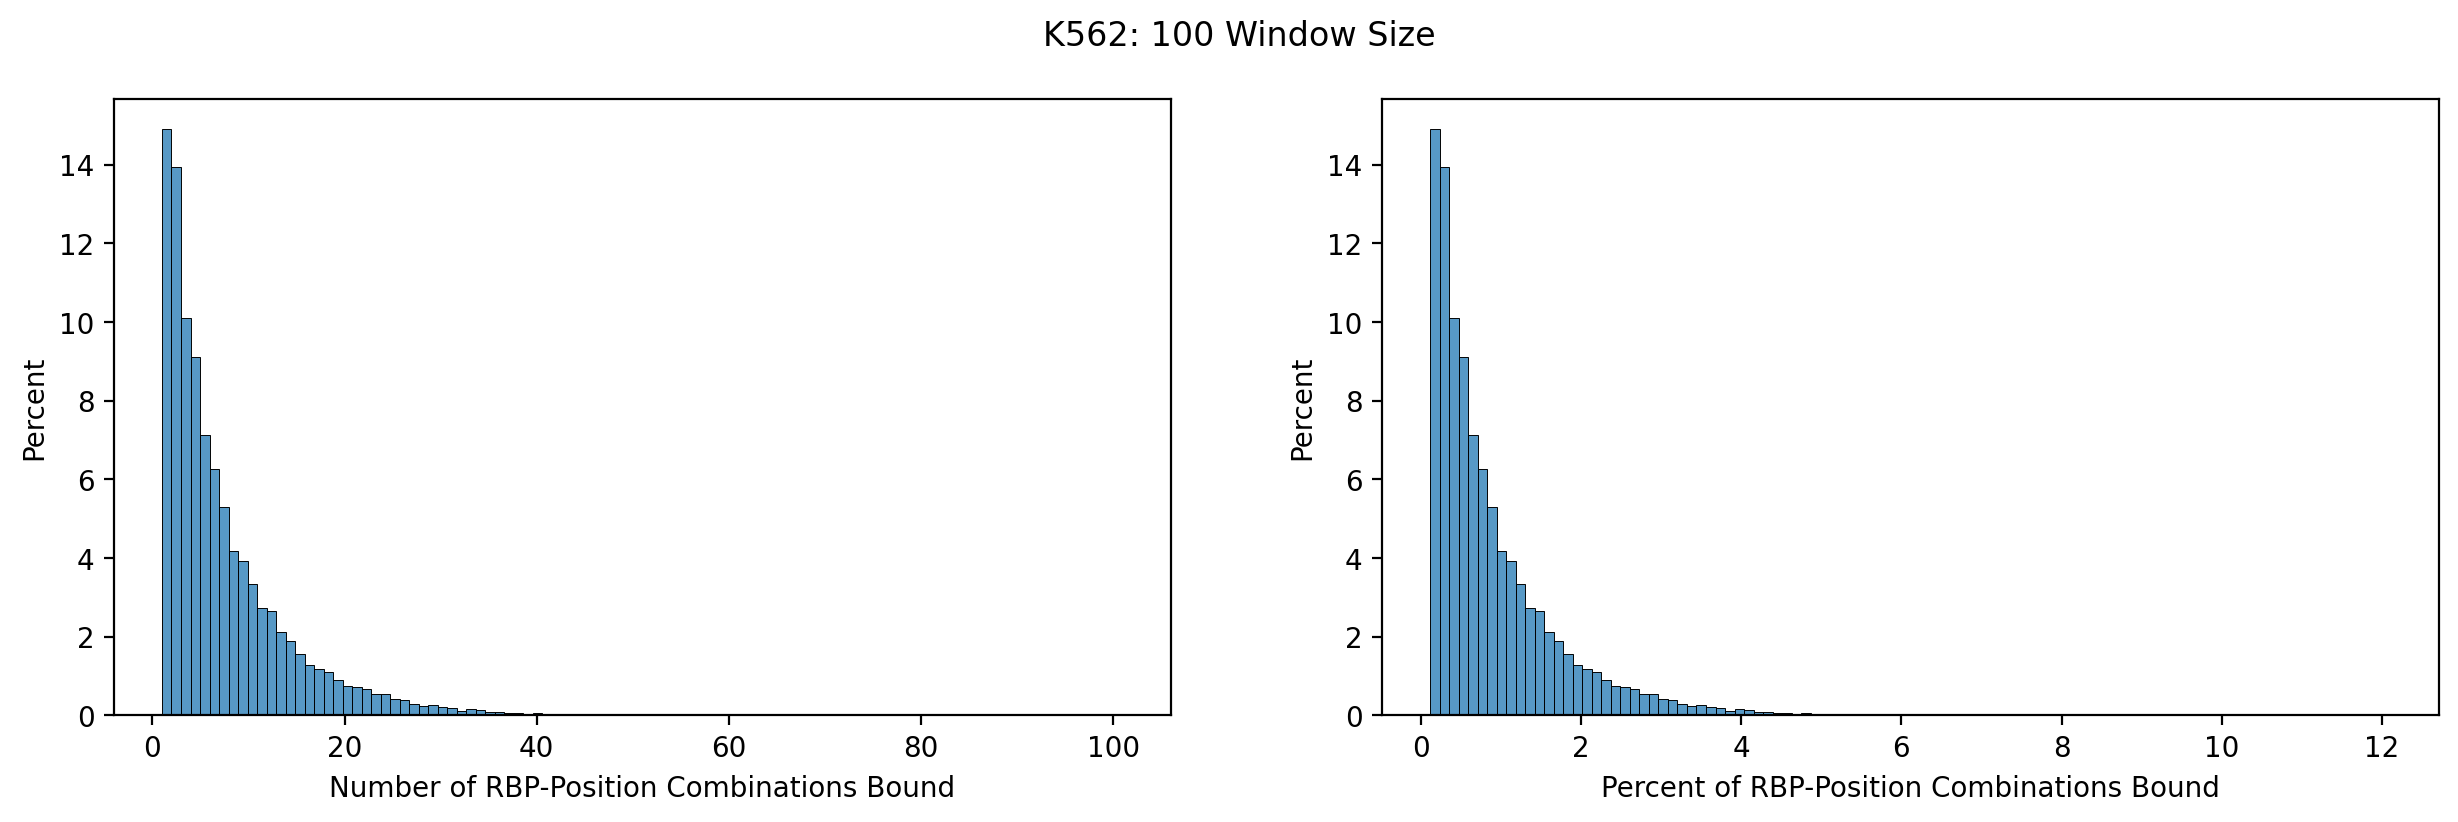

In [71]:

for cell_line in all_binding_data: 
    for window_size in all_binding_data[cell_line]:

        total_binding = all_binding_data[cell_line][window_size].sum(axis=1)
        percent_binding = ((all_binding_data[cell_line][window_size].sum(axis=1))/ len(all_binding_data[cell_line][window_size].columns))*100
                
        fig, ax = plt.subplots(1,2, dpi=200, figsize=(15,4))
        sns.histplot(
            total_binding,
            bins=total_binding.max(), 
            stat="percent",
            ax=ax[0]
        )
        sns.histplot(
            percent_binding,
            bins=total_binding.max(),
            stat="percent",
            ax=ax[1]
        )
        
        plt.suptitle("{}: {} Window Size".format(cell_line, window_size))
        ax[0].set(xlabel="Number of RBP-Position Combinations Bound")  
        ax[1].set(xlabel="Percent of RBP-Position Combinations Bound")  

        plt.show()

#### There are no events with 0 RBPs Binding!

#### Looks like Ayan has filtered those out. 

## Do RBPs Binding to `SE` Events Prefer Certain Positions?

NOTE: `Z-Scoring` columns that have only "0" as a value means they turn into "NaN" and are masked in certain visualizations.

Each plot below is sorted by one of the 6 positions to look for patterns

(6, 105)

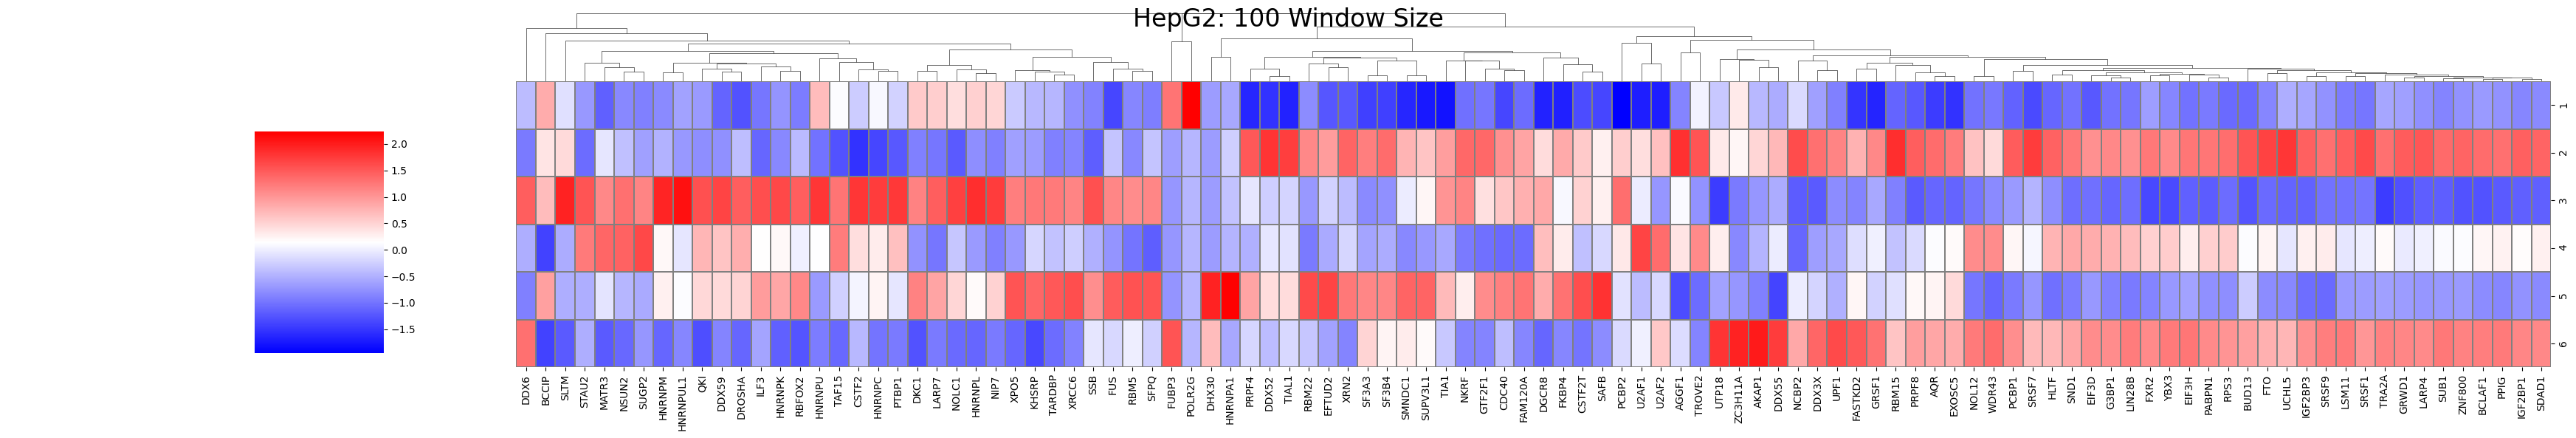

(6, 139)

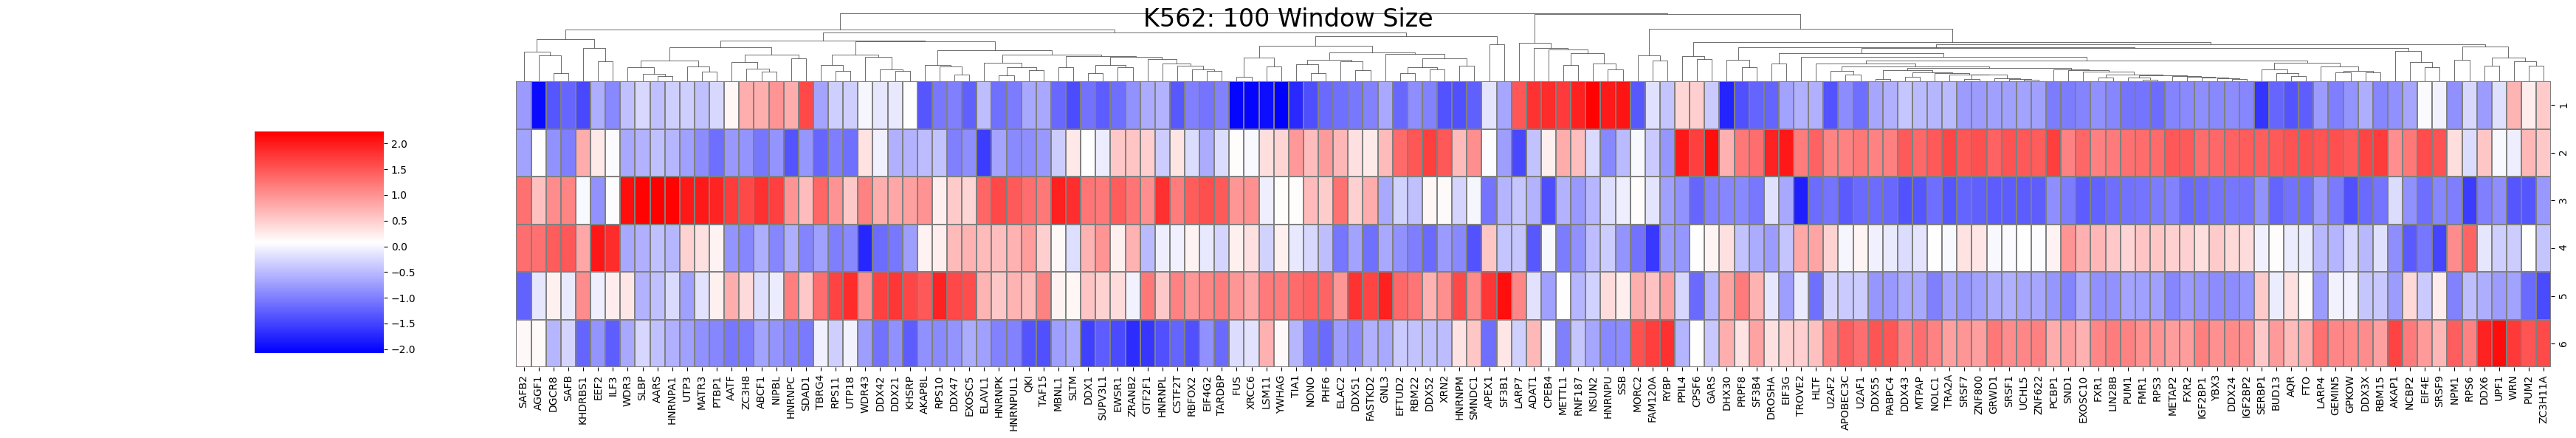

In [10]:
for cell_line in num_binding_sites: 
    for window_size in num_binding_sites[cell_line]: 

        num_binding_sites_df = rbp_by_position_matrix[cell_line][window_size]
        
        # z score normalize the columns (meaning that each RBP's values at 6 positions are z-scored) 
        # NOTE: columns with no variance become NaN
        num_binding_sites_df = num_binding_sites_df.apply(scipy.stats.zscore, axis="index", nan_policy="raise")  
        
        # remove columns that have NaN values after z score transformation 
        num_binding_sites_df = num_binding_sites_df.dropna(axis="columns", how="all")
                                
        # create clustermap but do not cluster by row as we want to see how the RBPs cluster by positions 
        sns.clustermap(
            num_binding_sites_df, 
            figsize=(35, 6), 
            linewidths=0.1, 
            linecolor="gray", 
            cmap="bwr", 
            row_cluster=False, 
            cbar_pos=(0.1, 0.2, 0.05, 0.5)
        )
        
        _=plt.suptitle("{}: {} Window Size".format(cell_line, window_size), fontsize=24,)

        plt.show()
        

### How do Hierarchical Clusterings (From Above) Compare Between Cell Lines?

* Need to look at BOTH:
    * RBPs profiled in both cell lines WHERE:
        * Both RBPs remain after `Z-Score Transformation` as RBPs with all "0" values are removed

In [103]:
# take the intersection of the RBPs left after Z scores between each cell line for each window size 
both_cell_line_profiled_rbps = {}

# can do this as the window sizes are same for both cell lines 
for window_size in rbp_by_position_matrix["K562"]: 

    similar_rbps = []
    
    for cell_line in ["K562", "HepG2"]: 

        num_binding_sites_df = rbp_by_position_matrix[cell_line][window_size]
        
        # z score normalize the columns (meaning that each RBP's values at 6 positions are z-scored) 
        # NOTE: columns with no variance become NaN
        num_binding_sites_df = num_binding_sites_df.apply(scipy.stats.zscore, axis="index", nan_policy="raise")  
        
        # remove columns that have NaN values after z score transformation 
        num_binding_sites_df = num_binding_sites_df.dropna(axis="columns", how="all")

        similar_rbps.append(set(num_binding_sites_df.columns.unique()))

    both_cell_line_profiled_rbps[window_size] = similar_rbps[0].intersection(similar_rbps[1])

In [104]:
for window_size in both_cell_line_profiled_rbps: 
    len(both_cell_line_profiled_rbps[window_size])
    print(both_cell_line_profiled_rbps[window_size])

75

{'TIA1', 'ZNF800', 'DROSHA', 'UCHL5', 'FUS', 'HNRNPU', 'HNRNPM', 'EFTUD2', 'FAM120A', 'HNRNPA1', 'TRA2A', 'DDX6', 'TARDBP', 'KHSRP', 'U2AF1', 'SRSF7', 'SRSF1', 'HNRNPUL1', 'NOLC1', 'LARP7', 'TROVE2', 'UPF1', 'SF3B4', 'SRSF9', 'PCBP1', 'PTBP1', 'NCBP2', 'XRCC6', 'PRPF8', 'ZC3H11A', 'GTF2F1', 'RBFOX2', 'CSTF2T', 'SDAD1', 'FTO', 'ILF3', 'SAFB', 'BUD13', 'DDX52', 'AQR', 'DDX3X', 'RBM15', 'IGF2BP1', 'AKAP1', 'FASTKD2', 'TAF15', 'HNRNPL', 'YBX3', 'SMNDC1', 'SND1', 'RPS3', 'LIN28B', 'WDR43', 'UTP18', 'GRWD1', 'DGCR8', 'NSUN2', 'HLTF', 'HNRNPC', 'AGGF1', 'U2AF2', 'EXOSC5', 'LARP4', 'MATR3', 'DDX55', 'QKI', 'RBM22', 'XRN2', 'SSB', 'SLTM', 'SUPV3L1', 'HNRNPK', 'DHX30', 'LSM11', 'FXR2'}


In [112]:
z_scored_matrices = {}

for window_size in both_cell_line_profiled_rbps: 
    z_scored_matrices[window_size] = {}
    
    for cell_line in ["K562", "HepG2"]: 

        num_binding_sites_df = rbp_by_position_matrix[cell_line][window_size]
          
        # z score normalize the columns (meaning that each RBP's values at 6 positions are z-scored) 
        # NOTE: columns with no variance become NaN
        num_binding_sites_df = num_binding_sites_df.apply(scipy.stats.zscore, axis="index", nan_policy="raise")  
        
        # remove columns that have NaN values after z score transformation 
        num_binding_sites_df = num_binding_sites_df.dropna(axis="columns", how="all")

        # subset only to those columns that are same between both cell lines 

        z_scored_matrices[window_size][cell_line] = num_binding_sites_df[list(both_cell_line_profiled_rbps[window_size])]


<Figure size 3200x2400 with 0 Axes>

<Figure size 3200x2400 with 0 Axes>

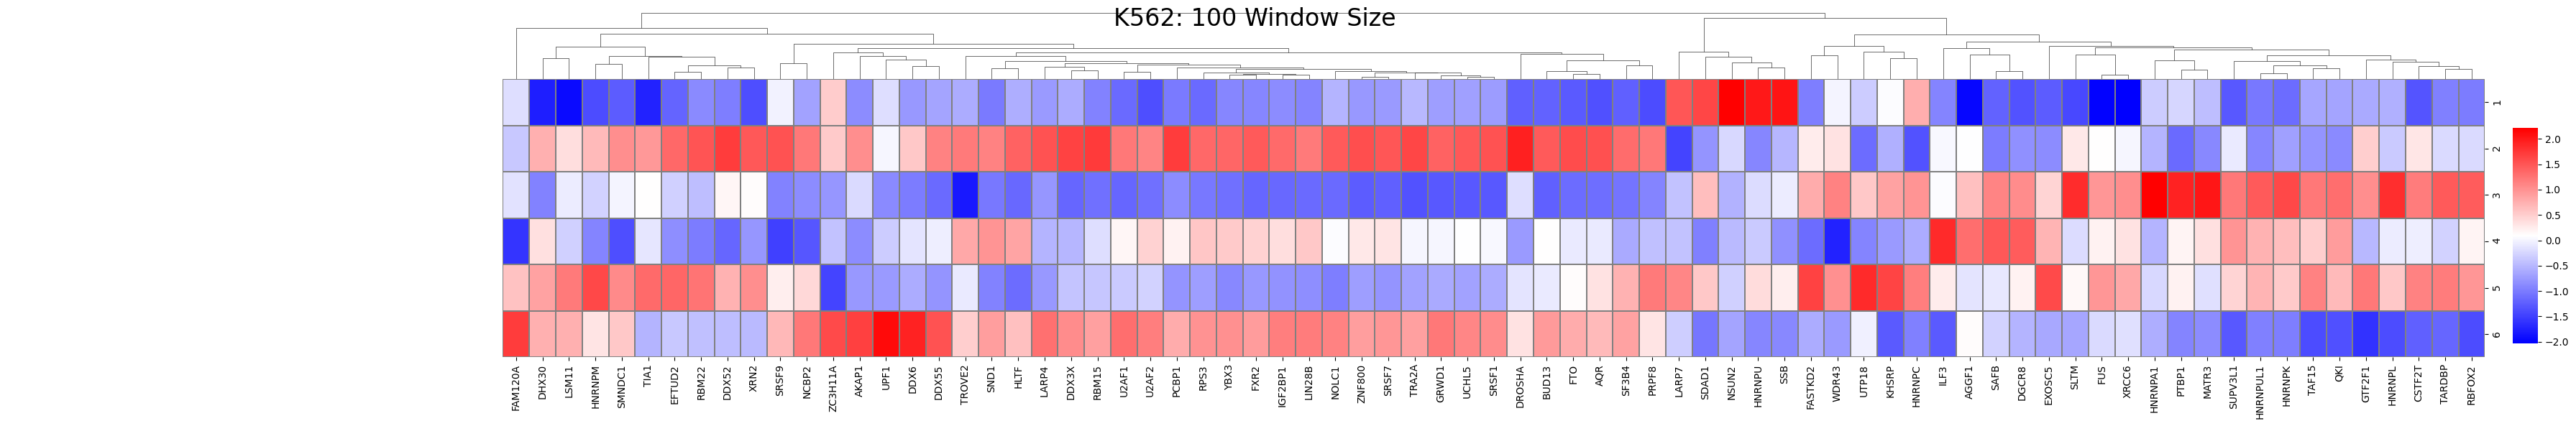

<Figure size 4000x400 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'HepG2: 100 window size')

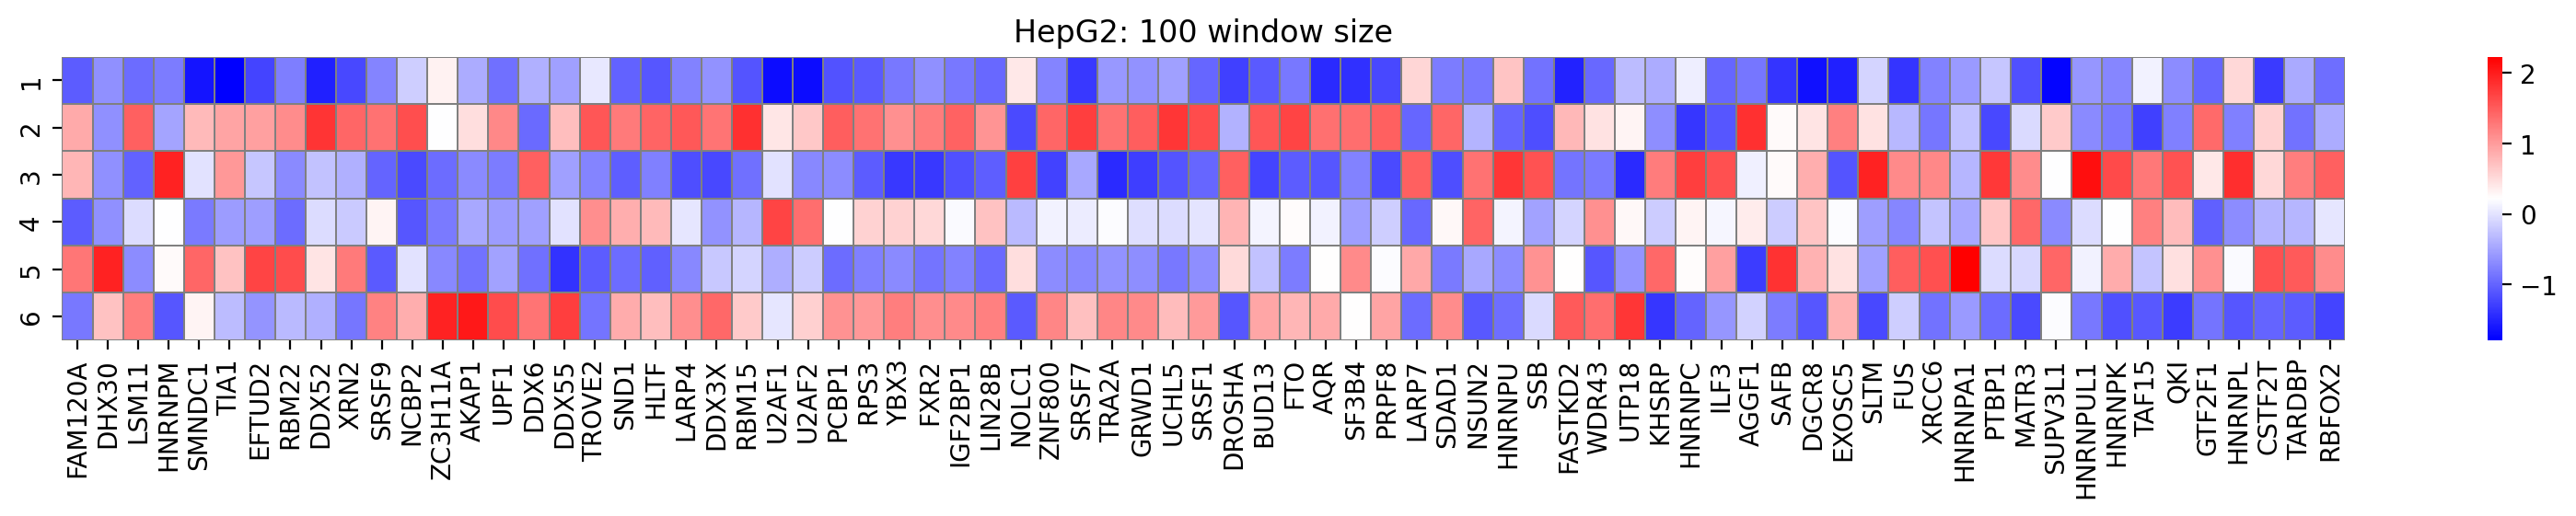

<Figure size 3200x2400 with 0 Axes>

<Figure size 3200x2400 with 0 Axes>

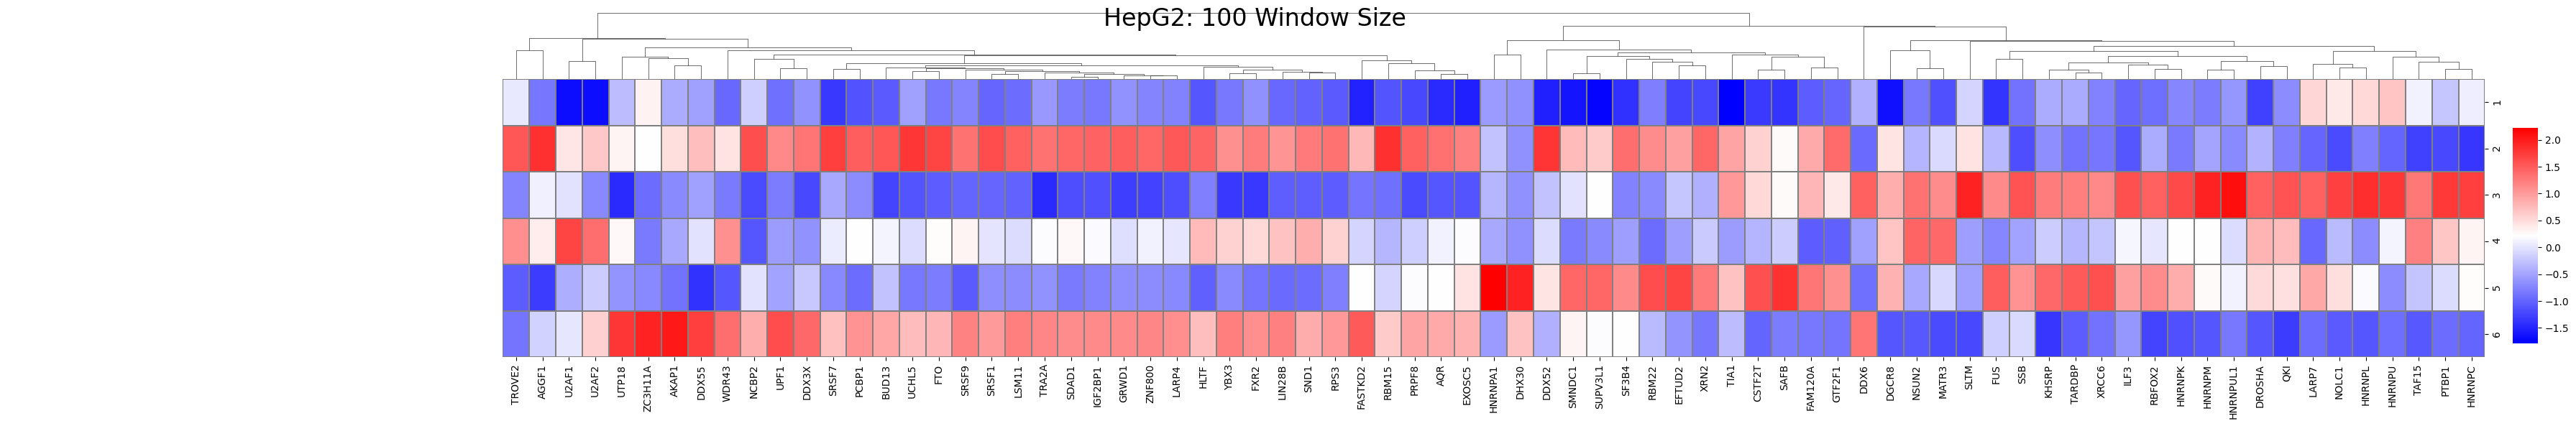

<Figure size 4000x400 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'K562: 100 window size')

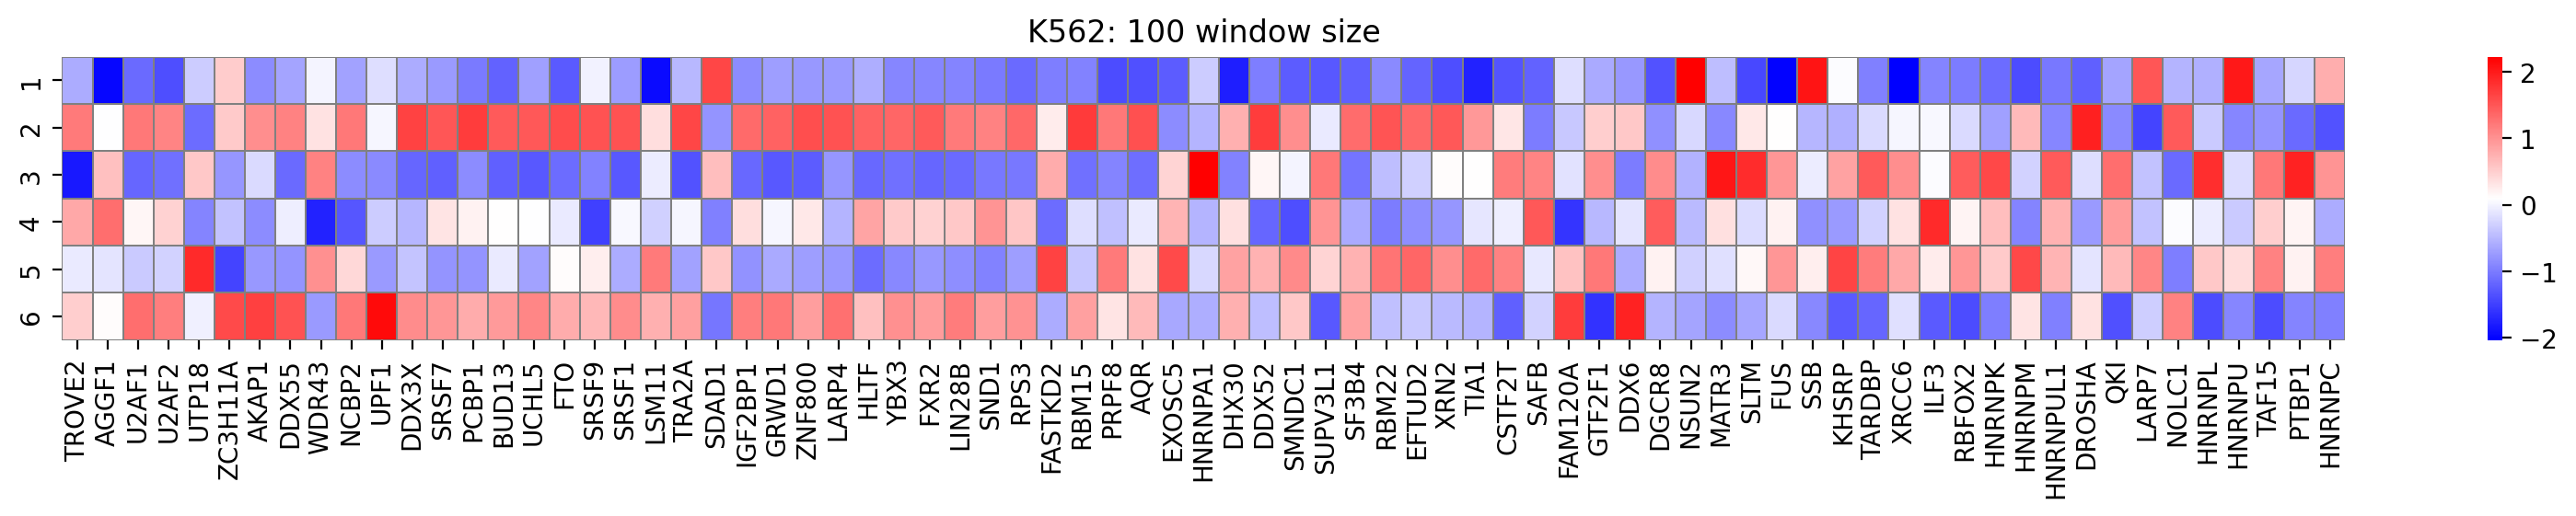

In [150]:
for window_size in z_scored_matrices:

    plt.figure(dpi=500)
    # create clustermap but do not cluster by row as we want to see how the RBPs cluster by positions 
    cluster_map = sns.clustermap(
        z_scored_matrices[window_size]["K562"], 
        figsize=(35, 6), 
        linewidths=0.1, 
        linecolor="gray", 
        cmap="bwr", 
        row_cluster=False, 
        cbar_pos=(1, 0.2, 0.01, 0.5)
    )
    
    _=plt.suptitle("{}: {} Window Size".format("K562", window_size), fontsize=24,)

    plt.show()

    k562_label_order = [t.get_text() for t in cluster_map.ax_heatmap.xaxis.get_majorticklabels()]

    hepg2_heatmap = z_scored_matrices[window_size]["HepG2"][k562_label_order]

    plt.figure(dpi=200, figsize=(20,2))

    sns.heatmap(
        hepg2_heatmap,
        linewidths=0.1, 
        linecolor="gray", 
        cmap="bwr", 
    )

    plt.title("HepG2: {} window size".format(window_size))

    plt.show()

#################################################################################################################################################
# VICE VERSA 

    plt.figure(dpi=500)
    # create clustermap but do not cluster by row as we want to see how the RBPs cluster by positions 
    cluster_map = sns.clustermap(
        z_scored_matrices[window_size]["HepG2"], 
        figsize=(35, 6), 
        linewidths=0.1, 
        linecolor="gray", 
        cmap="bwr", 
        row_cluster=False, 
        cbar_pos=(1, 0.2, 0.01, 0.5)
    )
    
    _=plt.suptitle("{}: {} Window Size".format("HepG2", window_size), fontsize=24,)

    plt.show()

    hepg2_label_order = [t.get_text() for t in cluster_map.ax_heatmap.xaxis.get_majorticklabels()]

    k562_heatmap = z_scored_matrices[window_size]["K562"][hepg2_label_order]

    plt.figure(dpi=200, figsize=(20,2))

    sns.heatmap(
        k562_heatmap,
        linewidths=0.1, 
        linecolor="gray", 
        cmap="bwr", 
    )

    plt.title("K562: {} window size".format(window_size))

    plt.show()
        

## What RBP-Position Combinations Co-Occur The Most In Space?

Answer with Hamming distance between two vectors where each vector is an RBP-position combination

In [11]:
hamming_distances = {}

for cell_line in all_binding_data: 
    hamming_distances[cell_line] = {}
    
    for window_size in all_binding_data[cell_line]: 
        "{} {}".format(cell_line, window_size)
        
        tmp_distance = scipy.spatial.distance.pdist(
            all_binding_data[cell_line][window_size].T.to_numpy(), 
            metric="hamming"
        )
        
        hamming_distances[cell_line][window_size] = tmp_distance 
        
        tmp_distance.shape

'HepG2 100'

(198135,)

'K562 100'

(347361,)

In [12]:
clusterings = {}

for cell_line in hamming_distances: 
    clusterings[cell_line] = {}
    for window_size in hamming_distances[cell_line]: 
        clusterings[cell_line][window_size] = {}
                
        for method in linkage_methods: 
            clusterings[cell_line][window_size][method] = scipy.cluster.hierarchy.linkage(
                hamming_distances[cell_line][window_size], 
                method=method
                
            )

'HepG2 100'

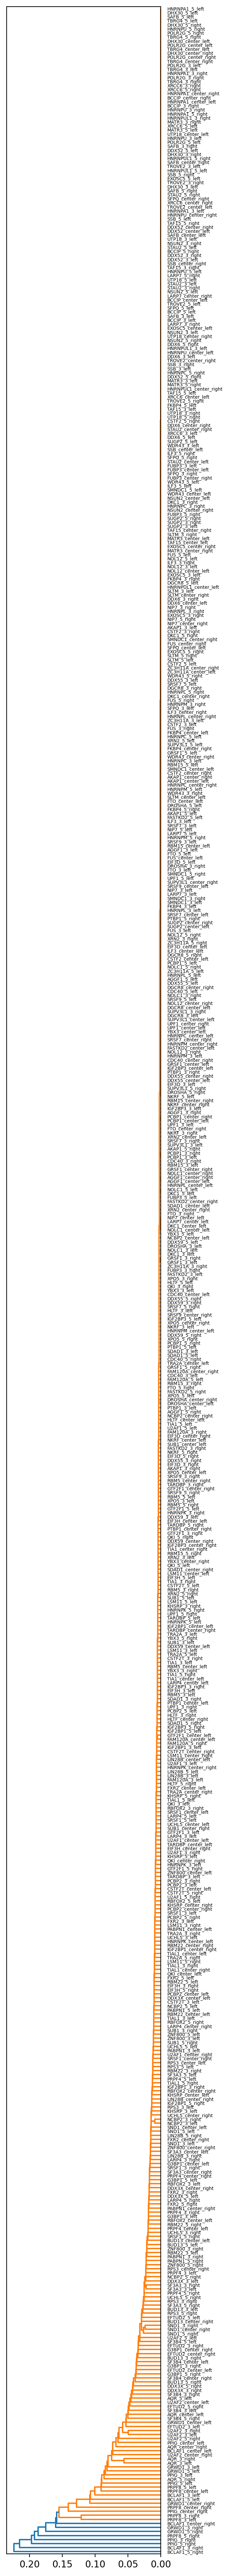

'K562 100'

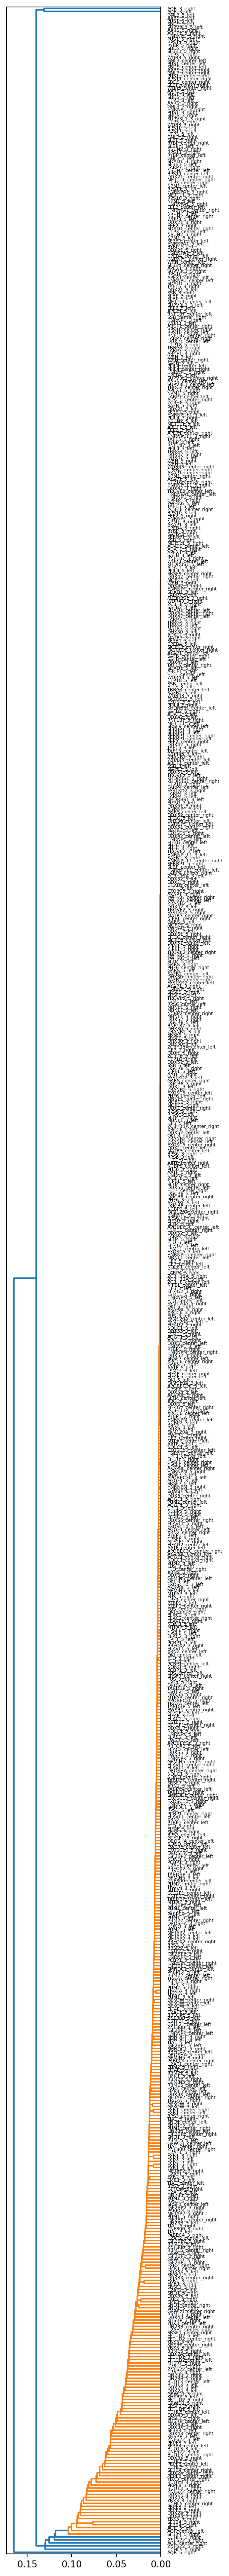

In [13]:
for cell_line in clusterings: 
    for window_size in clusterings[cell_line]: 
            
        "{} {}".format(cell_line, window_size)

        _=plt.figure(figsize=(3, 50), dpi=200)

        _=scipy.cluster.hierarchy.dendrogram(
            clusterings[cell_line][window_size]["average"], 
            get_leaves=True,
            labels = all_binding_data[cell_line][window_size].columns, 
            orientation="left"
        )

        plt.show()

## Unique Binding Patterns

* How many unique patterns exist?
* What are the most common ones?
* Which binding patterns have PSI values that have the least amount of variance?
    * Only meaningful if the binding pattern is somewhat interesting and "in-silico" KDs mimic the pattern 

In [14]:
unique_binding_patterns = {}

for cell_line in all_binding_data: 
    unique_binding_patterns[cell_line] = {}
    for window_size in all_binding_data[cell_line]:

        tmp_df = all_binding_data[cell_line][window_size].value_counts().reset_index()
        assert tmp_df.notna().any().any()

        assert tmp_df.index.size == tmp_df.drop_duplicates().index.size
        
        unique_binding_patterns[cell_line][window_size] = tmp_df
            

C:\Users\yragh\AppData\Local\Temp\ipykernel_21372\2436628152.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  tmp_df = all_binding_data[cell_line][window_size].value_counts().reset_index()
C:\Users\yragh\AppData\Local\Temp\ipykernel_21372\2436628152.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  tmp_df = all_binding_data[cell_line][window_size].value_counts().reset_index()
C:\Users\yragh\AppData\Local\Temp\ipykernel_21372\2436628152.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of 

In [15]:
for cell_line in unique_binding_patterns: 
    for window_size in unique_binding_patterns[cell_line]: 

        "Number of unique binding patterns for {} {}".format(cell_line, window_size)
        unique_binding_patterns[cell_line][window_size].index.size

'Number of unique binding patterns for HepG2 100'

45343

'Number of unique binding patterns for K562 100'

49628

<Figure size 4000x1000 with 0 Axes>

<Axes: xlabel='count', ylabel='Count'>

Text(0.5, 1.0, 'HepG2 100')

Text(0.5, 0, 'Unique Binding Pattern #')

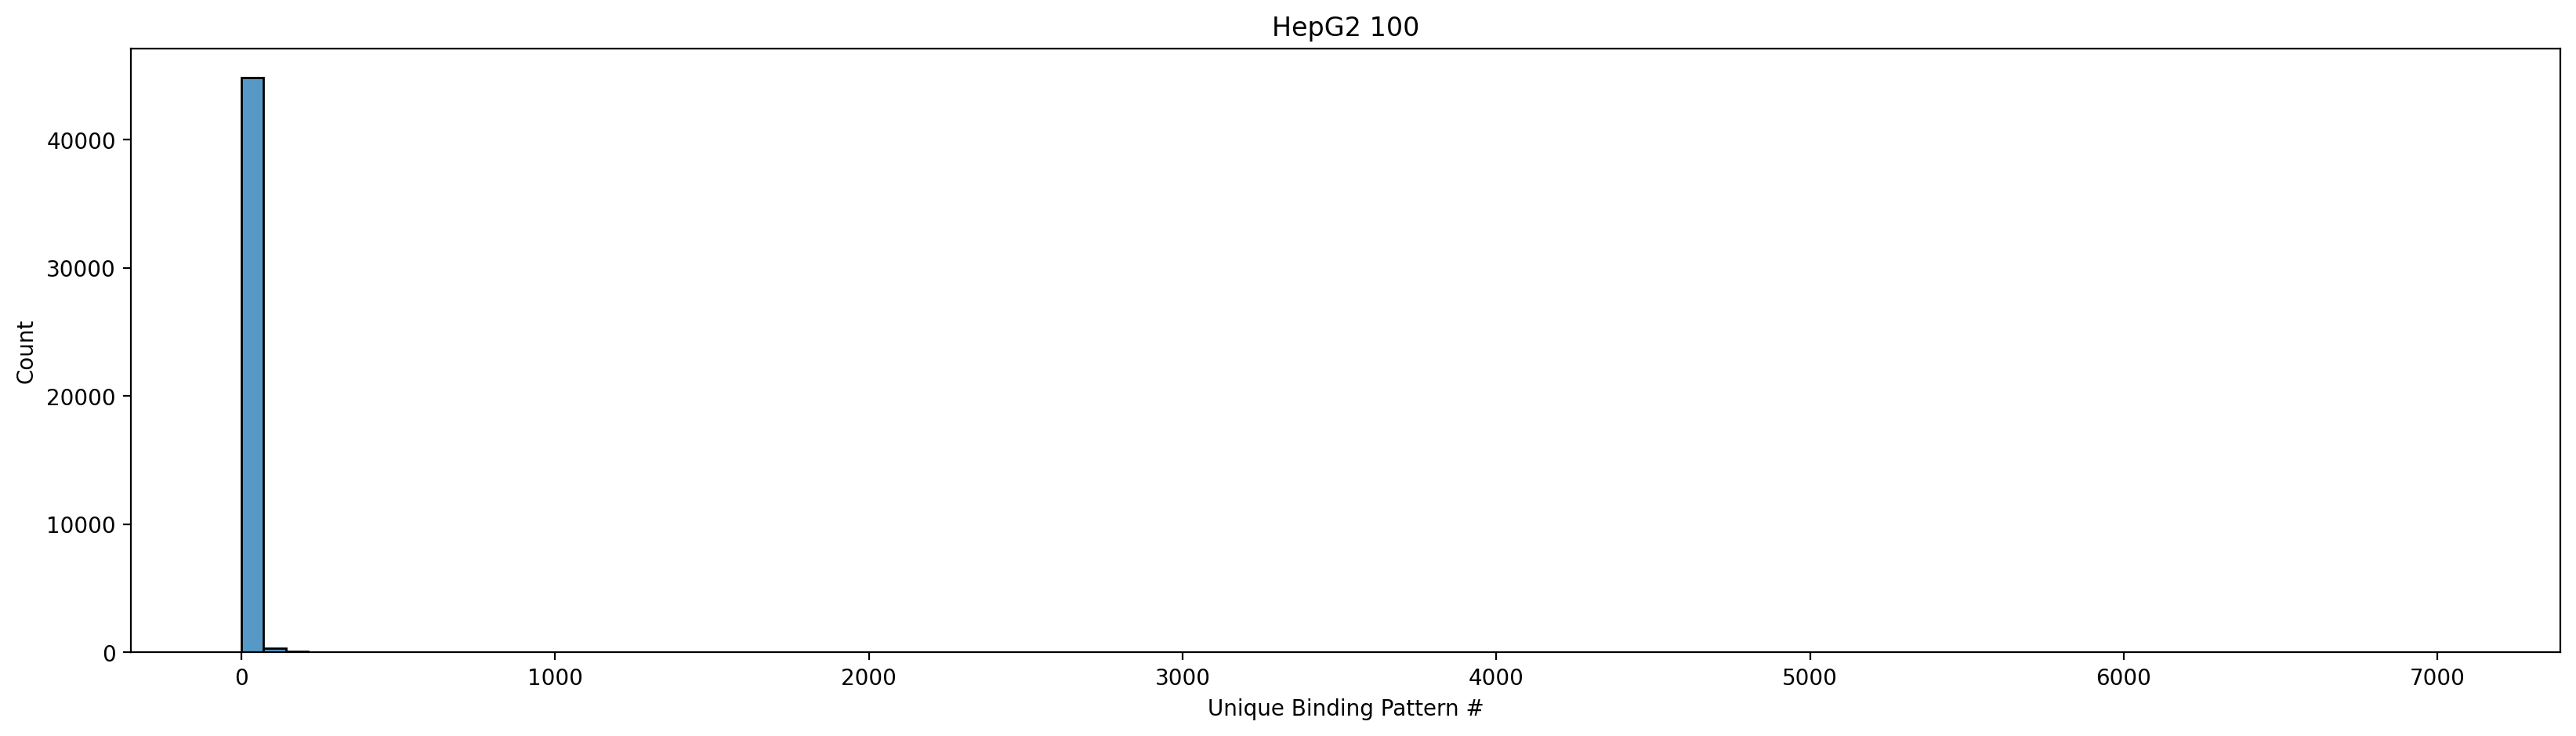

<Figure size 4000x1000 with 0 Axes>

<Axes: xlabel='count', ylabel='Count'>

Text(0.5, 1.0, 'K562 100')

Text(0.5, 0, 'Unique Binding Pattern #')

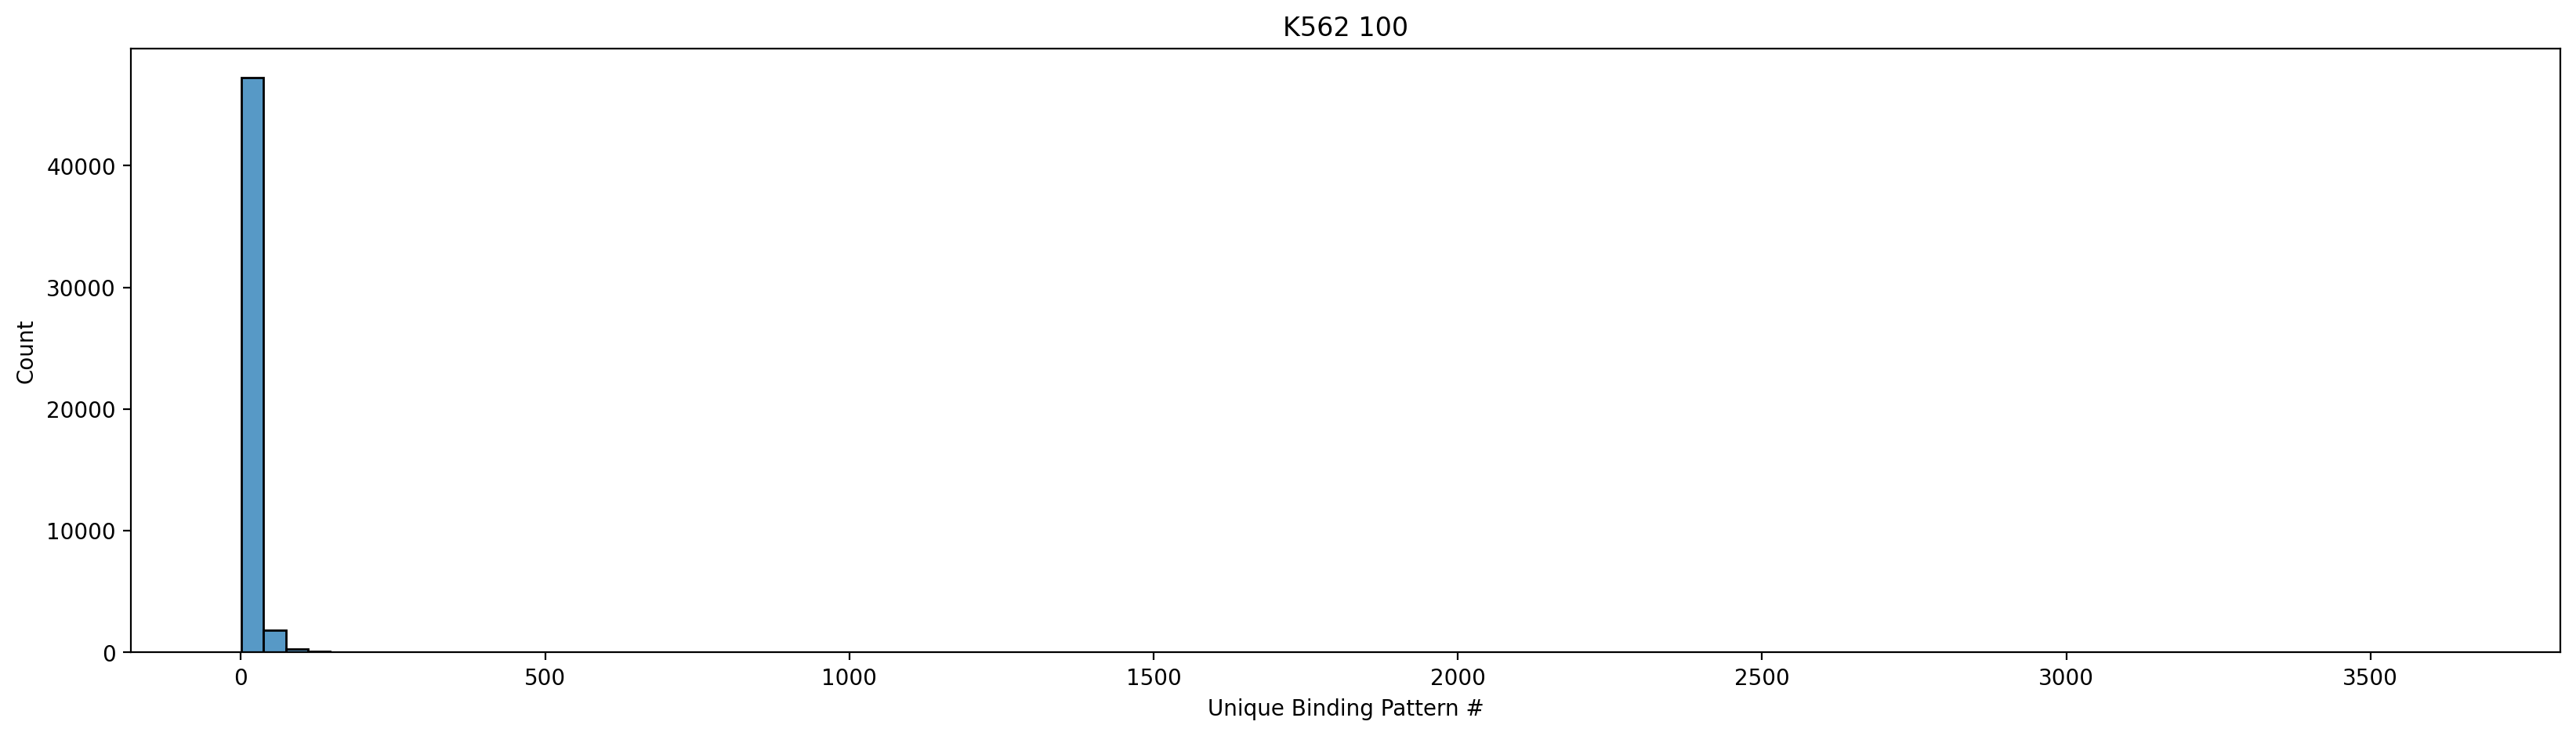

In [16]:
for cell_line in unique_binding_patterns: 
    for window_size in unique_binding_patterns[cell_line]: 

        plt.figure(dpi=200, figsize=(20, 5))

        sns.histplot(
            unique_binding_patterns[cell_line][window_size]["count"], 
            bins=100
        )
        plt.title("{} {}".format(cell_line, window_size))
        plt.xlabel("Unique Binding Pattern #")
        plt.show()
        